# Route Vulnerability Clustering: Which Canada-U.S. Air Routes Break First?

## Introduction

In February 2026, WestJet pulled 15 to 17 transborder routes from its summer schedule, slashing U.S. capacity by about 32% in Available Seat Miles. Air Transat will exit the U.S. market entirely by June. Flair Airlines cut U.S.-bound capacity by 58%. The trigger: a 24% year-over-year drop in Canadian return trips to the U.S., driven by the Trump administration's 25% tariff on Canadian goods and talk of Canada becoming the "51st state" [1]. Canadians responded with a broad "Buy Canadian" boycott, and airlines followed the money elsewhere.

But not all routes suffered equally. WestJet's Calgary-to-Nashville and Edmonton-to-Las Vegas got axed, while Toronto-to-New York survived. Why? What separates a fragile route from a resilient one? That question matters for network planners who need to prepare contingency schedules before the next demand shock hits.

This notebook uses **unsupervised machine learning** to answer that question. We will cluster Canada-U.S. transborder routes by their structural features (distance, passenger volume, seasonality, carrier concentration, and more) and then check whether the clusters that emerge naturally line up with the routes WestJet actually cancelled. **AI does not need to be told which routes are vulnerable. It discovers the pattern from data.**

## Environment Setup

This demo runs on a MacBook Pro with an Apple M2 processor and 8 GB of memory. All code uses Python and runs locally.

**Prerequisite:**
Install [Miniconda](https://www.anaconda.com/docs/getting-started/miniconda/install).

**Terminal commands to create the environment:**
```bash
# Create and activate the conda environment
conda create -n route-clustering python=3.10 -y
conda activate route-clustering

# Install core libraries
conda install -c conda-forge numpy pandas matplotlib seaborn scikit-learn scipy jupyter jupyterlab ipython pillow plotly -y
pip install umap-learn pymupdf

# Register the kernel
python -m ipykernel install --user --name route-clustering --display-name "Python (route-clustering)"

# Clear cache
conda clean -a -y && pip cache purge
```

In [4]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import gc
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Dimensionality reduction
import umap

# Hierarchical clustering dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Statistical testing
from scipy.stats import chi2_contingency

# Interactive visualization
import plotly.express as px
import plotly.graph_objects as go

# Display utilities
import pymupdf as fitz
from IPython.display import Image as IPythonImage
from IPython.display import display, SVG

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.precision', 2)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Utility function to display image (png, jpg, pdf, svg) in Jupyter
def show_image(image_path, width=500, page_num=0, dpi=300):
    if image_path.lower().endswith('.pdf'):
        doc = fitz.open(image_path)
        page = doc.load_page(page_num)
        pix = page.get_pixmap(dpi=dpi)
        img_data = pix.tobytes("png")
        doc.close()
        display(IPythonImage(data=img_data, width=width))
    elif image_path.lower().endswith('.svg'):
        display(SVG(image_path))
    else:
        display(IPythonImage(filename=image_path, width=width))

## What is Clustering?

Clustering is an **unsupervised learning** technique. Unlike supervised learning where we train a model on labeled data ("this route is vulnerable, this one isn't"), clustering finds natural groupings in data without any labels at all [2]. The algorithm looks at the features of each data point and groups similar points together.

Think of it like sorting a pile of airline routes into folders. You do not write the folder labels first. Instead, you spread out the routes on a table, notice that some share similar traits (short distance, high business traffic, hub endpoints), and naturally push them into the same pile. Clustering does this automatically, using math to measure "similarity."

In this demo, we use two popular clustering methods and compare them.

### K-Means Clustering

K-Means is probably the most widely used clustering algorithm [2]. The idea is simple:

1. Pick $k$ random points as initial cluster centers (called **centroids**).
2. Assign every data point to the nearest centroid.
3. Recompute each centroid as the average of all points assigned to it.
4. Repeat steps 2-3 until the assignments stop changing.

The algorithm minimizes the **within-cluster sum of squares** (WCSS), also called inertia:

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - \mu_i \|^2$$

where $C_i$ is the set of points in cluster $i$ and $\mu_i$ is the centroid of cluster $i$ [2].

**The catch**: you must choose $k$ ahead of time. We will use the **elbow method** and **silhouette score** to pick the right number.

### Hierarchical (Agglomerative) Clustering

Hierarchical clustering takes a different approach. Instead of picking $k$ upfront, it builds a tree-like structure called a **dendrogram** [3]:

1. Start with every data point as its own cluster (so $n$ clusters for $n$ points).
2. Find the two closest clusters and merge them into one.
3. Repeat until all points belong to a single cluster.

The result is a hierarchy that you can "cut" at any level to get different numbers of clusters. We use **Ward's linkage**, which merges the pair of clusters that causes the smallest increase in total within-cluster variance. This criterion tends to produce compact, evenly sized clusters [3].

The advantage over K-Means: you get a visual map (the dendrogram) that shows the full structure, not just one partition. The downside: it can be slower for very large datasets, though our 80-100 routes are no problem.

### K-Means vs. Hierarchical Clustering

| Aspect | K-Means | Hierarchical (Agglomerative) |
|--------|---------|------------------------------|
| Number of clusters | Must choose $k$ before running | Can decide after, by cutting the dendrogram |
| Speed | Fast, scales well to large data | Slower for large datasets ($O(n^2)$ or worse) |
| Output | Flat partition into $k$ groups | Full tree (dendrogram) showing nested relationships |
| Shape of clusters | Tends to find spherical clusters | Can handle more irregular shapes depending on linkage |
| Reproducibility | Results can vary with random initialization | Deterministic (same input always gives same tree) |

In practice, running both and comparing their results is a good way to check whether the clusters are robust or just artifacts of one particular algorithm [2][3].

### Choosing the Right Number of Clusters: Silhouette Score

How do you know if your clusters are actually meaningful? The **silhouette score** measures how well each data point fits within its assigned cluster compared to the nearest neighboring cluster [4].

For a single data point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where:
- $a(i)$ = average distance from point $i$ to all other points in the **same** cluster (how tight the cluster is)
- $b(i)$ = average distance from point $i$ to all points in the **nearest other** cluster (how separated the clusters are)

The score ranges from -1 to +1:
- **+1**: the point is far from neighboring clusters (good fit)
- **0**: the point is on the boundary between two clusters
- **-1**: the point is probably in the wrong cluster

We average $s(i)$ across all points to get the overall silhouette score. A score above 0.4 generally indicates reasonable structure, and above 0.5 is strong [4].

### UMAP: Seeing High-Dimensional Data in 2D

Our routes have 8 features. You cannot plot 8 dimensions on a screen. **UMAP** (Uniform Manifold Approximation and Projection) is a dimensionality reduction technique that projects high-dimensional data down to 2D (or 3D) while preserving the local neighborhood structure [5]. Points that were close together in 8D stay close in 2D.

UMAP works by:
1. Building a weighted graph of nearest neighbors in the high-dimensional space.
2. Optimizing a low-dimensional layout so the graph structure is preserved as closely as possible.

It is similar to t-SNE but tends to better preserve the global structure (spacing between clusters) and runs faster [5]. We use UMAP purely for visualization. The clustering itself still runs on the original 8-dimensional features.

### Our Approach

Here is the plan for this demo:

1. **Build a dataset** of ~90 synthetic Canada-U.S. transborder routes, each described by 8 features (distance, passengers, seasonality, frequency, carrier concentration, hub dependency, business share, and low-cost carrier penetration).
2. **Standardize** the features so they are on the same scale.
3. **Run K-Means** clustering for different values of $k$ and pick the best one using the elbow method and silhouette score.
4. **Run hierarchical clustering** with Ward's linkage and compare results using the Adjusted Rand Index.
5. **Visualize** the clusters in 2D using UMAP.
6. **Overlay** the WestJet cancellation data to see which clusters contain the cancelled routes.
7. **Test** whether cluster membership predicts route cancellation using a chi-squared test.

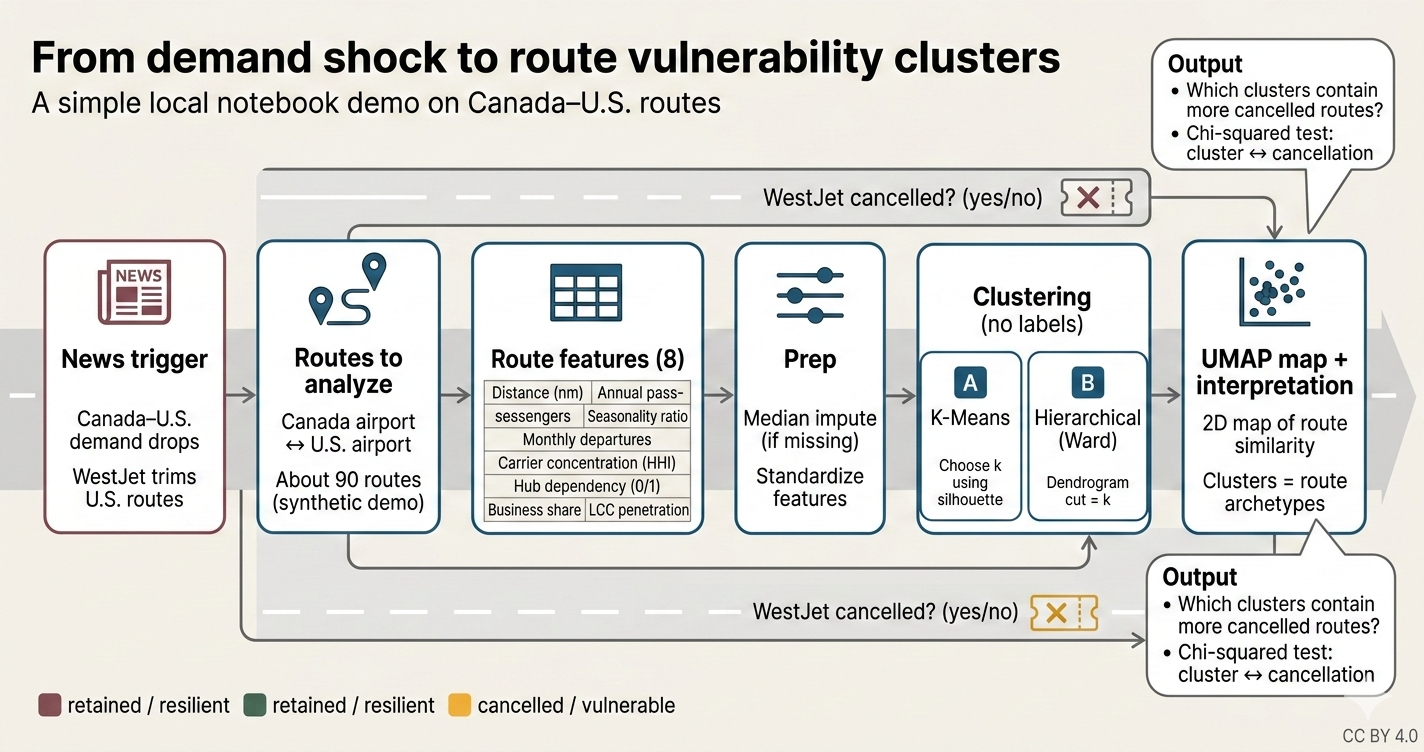

In [5]:
show_image('assets/pipeline-dev.png', width=900)

Figure: This diagram shows the full flow of the demo. We start from a real demand shock in Canada–U.S. travel and build a simple dataset of transborder routes. Each route is described by 8 plain features such as distance, passengers, and seasonality. After basic cleaning and standardization, we group routes using clustering, which does not need labels. We then visualize the route groups on a 2D UMAP map and overlay which routes were reportedly cancelled to see whether some route types are more fragile under a demand shift.

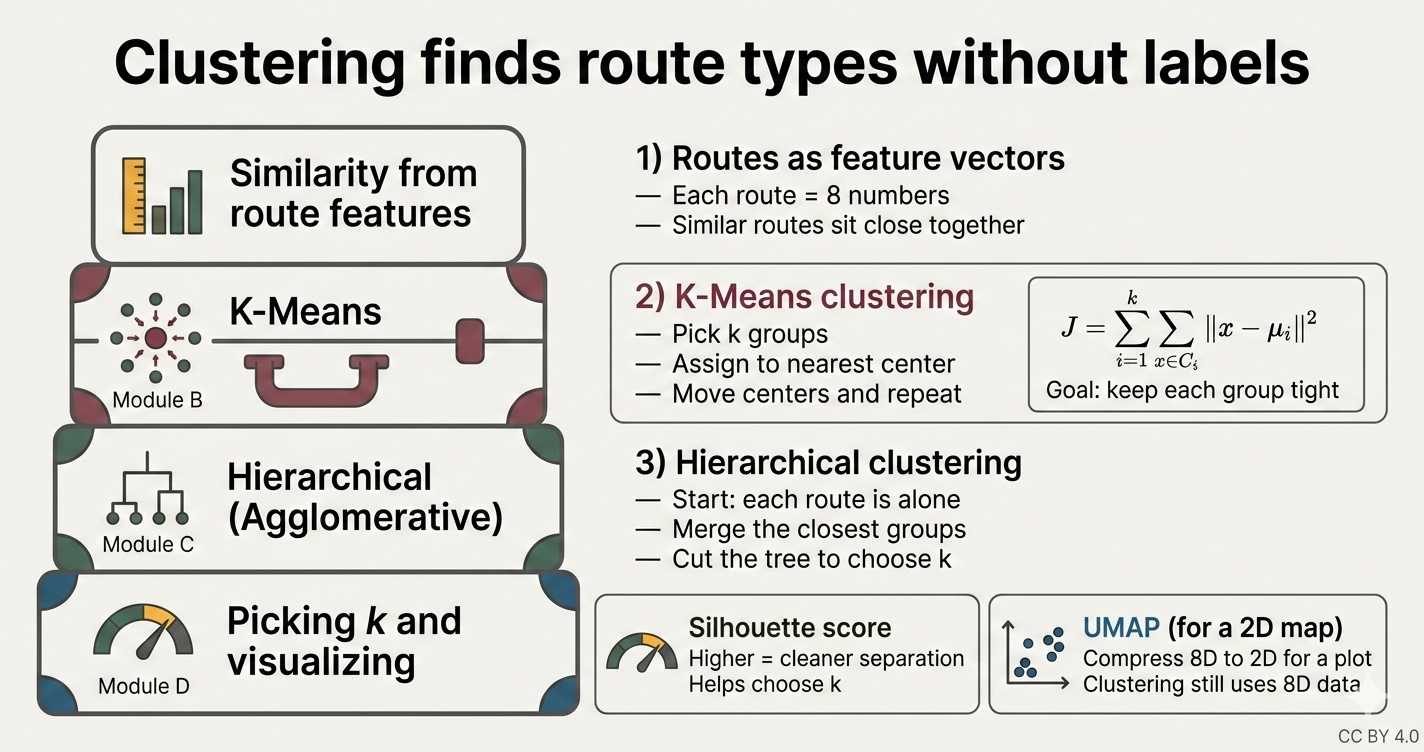

In [6]:
show_image('assets/aitheory-dev.png', width=900)

Figure: This diagram summarizes the AI ideas used in the demo. We turn each route into a small set of numeric features, then apply clustering to group routes that look similar. K-Means forms k groups by repeatedly assigning routes to the nearest center and moving the centers to reduce within-group spread. Hierarchical clustering builds a merge tree that can be cut to get k groups. We use silhouette score to pick a reasonable k, and we use UMAP to draw a 2D map so humans can see how the route groups separate.

## Dataset

> **DISCLAIMER**: All data in this notebook is **synthetic and hypothetical**. Aircraft specifications, route information, and performance metrics are rough estimates based on publicly available industry benchmarks. This data does not represent actual airline operational data. This demonstration is for educational purposes only to illustrate AI concepts.

### Route Selection

We start by defining a set of Canada-U.S. transborder routes. Each route is an origin-destination pair between a Canadian and a U.S. airport. We include a mix of:

- **Hub routes** from major Canadian airports (YYZ, YVR, YYC, YUL) to large U.S. cities
- **Secondary market routes** from smaller Canadian cities (YEG, YWG, YOW, YHZ, YLW) to U.S. destinations
- **Leisure-heavy routes** to Florida and Las Vegas
- **Business corridors** like Toronto-New York and Montreal-New York

We aim for roughly 90 routes, reflecting the real scale of Canada-U.S. transborder flying. The routes below are based on publicly known city pairs that Canadian carriers have operated or considered in recent years [6].

In [59]:
np.random.seed(42)

# Canadian airports
hubs_ca = ['YYZ', 'YVR', 'YYC', 'YUL']
secondary_ca = ['YEG', 'YWG', 'YOW', 'YHZ', 'YLW', 'YQB', 'YXE', 'YQR']

# U.S. airports
major_us = ['JFK', 'LAX', 'SFO', 'ORD', 'ATL', 'MIA', 'BOS', 'SEA',
            'LAS', 'PHX', 'DEN', 'DFW', 'MCO', 'EWR', 'IAD', 'DTW', 'MSP']
leisure_us = ['TPA', 'FLL', 'RSW', 'PBI', 'HNL', 'SAN', 'PSP']
secondary_us = ['BNA', 'AUS', 'PDX', 'SJC', 'PIT', 'CLE', 'MCI', 'RDU', 'BUF', 'SNA']

# Build the route list
routes = []

# Hub-to-major-US routes (the backbone)
hub_major_pairs = [
    ('YYZ', 'JFK'), ('YYZ', 'LAX'), ('YYZ', 'SFO'), ('YYZ', 'ORD'),
    ('YYZ', 'ATL'), ('YYZ', 'MIA'), ('YYZ', 'BOS'), ('YYZ', 'DFW'),
    ('YYZ', 'DEN'), ('YYZ', 'EWR'), ('YYZ', 'IAD'), ('YYZ', 'SEA'),
    ('YYZ', 'LAS'), ('YYZ', 'MCO'), ('YYZ', 'DTW'), ('YYZ', 'MSP'),
    ('YVR', 'LAX'), ('YVR', 'SFO'), ('YVR', 'SEA'), ('YVR', 'PHX'),
    ('YVR', 'LAS'), ('YVR', 'DEN'), ('YVR', 'ORD'),
    ('YYC', 'LAX'), ('YYC', 'SFO'), ('YYC', 'SEA'), ('YYC', 'PHX'),
    ('YYC', 'DEN'), ('YYC', 'LAS'), ('YYC', 'ORD'),
    ('YUL', 'JFK'), ('YUL', 'EWR'), ('YUL', 'BOS'), ('YUL', 'MIA'),
    ('YUL', 'ORD'), ('YUL', 'IAD'), ('YUL', 'ATL'),
]

# Hub-to-leisure-US routes
hub_leisure_pairs = [
    ('YYZ', 'TPA'), ('YYZ', 'FLL'), ('YYZ', 'RSW'), ('YYZ', 'PBI'),
    ('YYZ', 'SAN'), ('YYZ', 'HNL'), ('YYZ', 'PSP'),
    ('YVR', 'MCO'), ('YVR', 'FLL'), ('YVR', 'PSP'), ('YVR', 'SAN'),
    ('YYC', 'MCO'), ('YYC', 'TPA'), ('YYC', 'FLL'),
    ('YUL', 'FLL'), ('YUL', 'TPA'), ('YUL', 'MCO'),
]

# Hub-to-secondary-US routes
hub_secondary_pairs = [
    ('YYZ', 'BNA'), ('YYZ', 'AUS'), ('YYZ', 'PDX'), ('YYZ', 'PIT'),
    ('YYC', 'BNA'), ('YYC', 'SAN'), ('YYC', 'ATL'),
    ('YVR', 'ATL'), ('YVR', 'BNA'),
    ('YUL', 'BNA'), ('YUL', 'DFW'),
]

# Secondary-CA to US routes (thinner markets)
secondary_pairs = [
    ('YEG', 'LAS'), ('YEG', 'PHX'), ('YEG', 'LAX'), ('YEG', 'SFO'),
    ('YEG', 'MCO'), ('YEG', 'SEA'),
    ('YWG', 'LAS'), ('YWG', 'MCO'), ('YWG', 'MSP'), ('YWG', 'PHX'),
    ('YOW', 'FLL'), ('YOW', 'MCO'), ('YOW', 'JFK'),
    ('YHZ', 'FLL'), ('YHZ', 'BOS'), ('YHZ', 'JFK'),
    ('YLW', 'LAS'), ('YLW', 'PHX'), ('YLW', 'SEA'),
    ('YQB', 'FLL'), ('YQB', 'MCO'),
]

routes = hub_major_pairs + hub_leisure_pairs + hub_secondary_pairs + secondary_pairs
print(f"Total routes defined: {len(routes)}")
print(f"  Hub-to-major-US: {len(hub_major_pairs)}")
print(f"  Hub-to-leisure-US: {len(hub_leisure_pairs)}")
print(f"  Hub-to-secondary-US: {len(hub_secondary_pairs)}")
print(f"  Secondary-CA-to-US: {len(secondary_pairs)}")

Total routes defined: 86
  Hub-to-major-US: 37
  Hub-to-leisure-US: 17
  Hub-to-secondary-US: 11
  Secondary-CA-to-US: 21


### Feature Engineering

For each route, we generate 8 features that capture its structural characteristics. These are the features that our clustering algorithm will use to find natural groupings:

| Feature | Description | Range |
|---------|-------------|-------|
| `distance_nm` | Great circle distance in nautical miles | ~150 to ~3,700 |
| `annual_pax` | Total annual passengers (both directions) | ~15,000 to ~2,000,000 |
| `seasonality_ratio` | Peak quarter passengers / trough quarter passengers | 1.0 to 4.5 |
| `monthly_departures` | Average monthly flight departures | 15 to 350 |
| `carrier_hhi` | Herfindahl-Hirschman Index measuring carrier concentration (higher = less competition) | 2,000 to 10,000 |
| `hub_dependency` | 1 if either endpoint is a major Canadian hub (YYZ, YVR, YYC, YUL), 0 otherwise | 0 or 1 |
| `business_share` | Estimated share of business travelers (based on day-of-week patterns) | 0.05 to 0.65 |
| `lcc_penetration` | Share of seats operated by low-cost carriers | 0.0 to 0.95 |

The Herfindahl-Hirschman Index (HHI) is a standard measure of market concentration [7]. It is calculated as the sum of squared market shares of all carriers on a route. An HHI of 10,000 means a single carrier monopoly. An HHI around 2,500 means roughly four equally sized carriers.

In [60]:
# Approximate coordinates for distance calculation (lat, lon)
airport_coords = {
    # Canadian airports
    'YYZ': (43.68, -79.63), 'YVR': (49.19, -123.18), 'YYC': (51.13, -114.01),
    'YUL': (45.47, -73.74), 'YEG': (53.31, -113.58), 'YWG': (49.91, -97.24),
    'YOW': (45.32, -75.67), 'YHZ': (44.88, -63.51), 'YLW': (49.96, -119.38),
    'YQB': (46.79, -71.39), 'YXE': (52.17, -106.70), 'YQR': (50.43, -104.67),
    # U.S. airports
    'JFK': (40.64, -73.78), 'LAX': (33.94, -118.41), 'SFO': (37.62, -122.38),
    'ORD': (41.98, -87.90), 'ATL': (33.64, -84.43), 'MIA': (25.80, -80.29),
    'BOS': (42.36, -71.01), 'SEA': (47.45, -122.31), 'LAS': (36.08, -115.15),
    'PHX': (33.43, -112.01), 'DEN': (39.86, -104.67), 'DFW': (32.90, -97.04),
    'MCO': (28.43, -81.31), 'EWR': (40.69, -74.17), 'IAD': (38.95, -77.46),
    'DTW': (42.21, -83.35), 'MSP': (44.88, -93.22), 'TPA': (27.98, -82.53),
    'FLL': (26.07, -80.15), 'RSW': (26.54, -81.76), 'PBI': (26.68, -80.10),
    'HNL': (21.32, -157.92), 'SAN': (32.73, -117.19), 'PSP': (33.83, -116.51),
    'BNA': (36.12, -86.68), 'AUS': (30.19, -97.67), 'PDX': (45.59, -122.60),
    'SJC': (37.36, -121.93), 'PIT': (40.49, -80.23), 'CLE': (41.41, -81.85),
    'MCI': (39.30, -94.71), 'RDU': (35.88, -78.79), 'BUF': (42.94, -78.73),
    'SNA': (33.68, -117.87),
}

def haversine_nm(coord1, coord2):
    """Calculate great circle distance between two points in nautical miles."""
    lat1, lon1 = np.radians(coord1)
    lat2, lon2 = np.radians(coord2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r_nm = 3440.065  # Earth radius in nautical miles
    return r_nm * c

# Calculate distance for each route
distances = []
for origin, dest in routes:
    d = haversine_nm(airport_coords[origin], airport_coords[dest])
    distances.append(round(d))

print(f"Distance range: {min(distances)} to {max(distances)} nm")
print(f"Mean distance: {np.mean(distances):.0f} nm")

Distance range: 110 to 4034 nm
Mean distance: 1086 nm


In [61]:
# Classify each route by type for realistic feature generation
leisure_destinations = {'TPA', 'FLL', 'RSW', 'PBI', 'HNL', 'MCO', 'PSP', 'LAS', 'PHX', 'SAN'}
business_destinations = {'JFK', 'EWR', 'IAD', 'ORD', 'BOS', 'DTW', 'MSP', 'DFW', 'SFO'}

route_types = []
for origin, dest in routes:
    is_hub = origin in hubs_ca
    is_leisure = dest in leisure_destinations
    is_business = dest in business_destinations
    is_secondary_origin = origin in secondary_ca

    if is_secondary_origin:
        route_types.append('secondary')
    elif is_hub and is_business:
        route_types.append('business')
    elif is_hub and is_leisure:
        route_types.append('leisure')
    else:
        route_types.append('mixed')

print("Route type distribution:")
for rt in ['business', 'leisure', 'mixed', 'secondary']:
    count = route_types.count(rt)
    print(f"  {rt}: {count}")

Route type distribution:
  business: 19
  leisure: 24
  mixed: 22
  secondary: 21


In [62]:
# Generate features based on route type and distance
data = []

for i, (origin, dest) in enumerate(routes):
    d = distances[i]
    rtype = route_types[i]
    is_hub = origin in hubs_ca

    # --- Annual passengers ---
    # Business corridors and hub routes get higher traffic
    if rtype == 'business' and d < 500:
        pax = np.random.randint(800_000, 2_000_000)       # short-haul business (YYZ-JFK etc.)
    elif rtype == 'business':
        pax = np.random.randint(200_000, 900_000)          # longer business routes
    elif rtype == 'leisure' and is_hub:
        pax = np.random.randint(150_000, 700_000)          # leisure from hubs
    elif rtype == 'mixed':
        pax = np.random.randint(100_000, 500_000)
    else:  # secondary
        pax = np.random.randint(15_000, 200_000)

    # --- Seasonality ratio (peak quarter / trough quarter) ---
    if rtype == 'business':
        season = round(np.random.uniform(1.05, 1.45), 2)   # business is steady year-round
    elif rtype == 'leisure':
        season = round(np.random.uniform(2.0, 4.5), 2)     # Florida/leisure = very seasonal
    elif rtype == 'mixed':
        season = round(np.random.uniform(1.3, 2.5), 2)
    else:  # secondary
        season = round(np.random.uniform(1.8, 4.0), 2)     # thin seasonal routes

    # --- Monthly departures ---
    # Scale roughly with passenger volume
    base_freq = pax / 180 / 30  # rough: pax per seat per month, ~180 seats, ~30 days
    monthly_dep = int(np.clip(base_freq * np.random.uniform(0.7, 1.3), 15, 350))

    # --- Carrier HHI ---
    # Hub business routes tend to have more competition; secondary routes are often monopolies
    if rtype == 'business':
        hhi = np.random.randint(2200, 5500)
    elif rtype == 'leisure' and is_hub:
        hhi = np.random.randint(3000, 7000)
    elif rtype == 'mixed':
        hhi = np.random.randint(3500, 7500)
    else:  # secondary
        hhi = np.random.randint(6000, 10000)

    # --- Hub dependency ---
    hub_dep = 1 if is_hub else 0

    # --- Business share proxy ---
    if rtype == 'business':
        biz_share = round(np.random.uniform(0.35, 0.65), 2)
    elif rtype == 'leisure':
        biz_share = round(np.random.uniform(0.05, 0.20), 2)
    elif rtype == 'mixed':
        biz_share = round(np.random.uniform(0.20, 0.40), 2)
    else:
        biz_share = round(np.random.uniform(0.08, 0.25), 2)

    # --- LCC penetration ---
    if rtype == 'business':
        lcc = round(np.random.uniform(0.05, 0.35), 2)
    elif rtype == 'leisure':
        lcc = round(np.random.uniform(0.40, 0.90), 2)
    elif rtype == 'mixed':
        lcc = round(np.random.uniform(0.20, 0.60), 2)
    else:
        lcc = round(np.random.uniform(0.30, 0.95), 2)

    data.append({
        'origin': origin,
        'destination': dest,
        'route': f"{origin}-{dest}",
        'route_type': rtype,
        'distance_nm': d,
        'annual_pax': pax,
        'seasonality_ratio': season,
        'monthly_departures': monthly_dep,
        'carrier_hhi': hhi,
        'hub_dependency': hub_dep,
        'business_share': biz_share,
        'lcc_penetration': lcc,
    })

df = pd.DataFrame(data)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (86, 12)


,origin,destination,route,route_type,distance_nm,annual_pax,seasonality_ratio,monthly_departures,carrier_hhi,hub_dependency,business_share,lcc_penetration
0,YYZ,JFK,YYZ-JFK,business,318,921958,1.37,138,3295,1,0.53,0.10
1,YYZ,LAX,YYZ-LAX,mixed,1887,187498,2.34,36,7235,1,0.33,0.22
2,YYZ,SFO,YYZ-SFO,business,1959,521879,1.38,79,3415,1,0.65,0.24
3,YYZ,ORD,YYZ-ORD,business,378,1789436,1.22,289,3282,1,0.47,0.06
4,YYZ,ATL,YYZ-ATL,mixed,643,102747,1.74,18,6234,1,0.32,0.35
5,YYZ,MIA,YYZ-MIA,mixed,1074,428947,2.01,57,7390,1,0.34,0.38
6,YYZ,BOS,YYZ-BOS,business,386,1149457,1.43,272,2441,1,0.47,0.05
7,YYZ,DFW,YYZ-DFW,business,1041,848531,1.15,174,4756,1,0.60,0.10
8,YYZ,DEN,YYZ-DEN,mixed,1140,398064,1.61,80,6573,1,0.29,0.28
9,YYZ,EWR,YYZ-EWR,business,302,1071836,1.44,231,2361,1,0.47,0.33


### Cancellation Labels

Next, we add a binary label indicating whether WestJet cancelled the route in its Summer 2026 schedule adjustment. According to the news, WestJet removed 15 to 17 transborder routes from cities including Calgary, Vancouver, Edmonton, Toronto, Winnipeg, and Kelowna to U.S. destinations such as Nashville, San Francisco, Tampa, San Diego, Atlanta, Orlando, and Seattle [1].

We label 15 routes as cancelled based on these reported city pairs. This is our ground truth for evaluating how well the clusters separate vulnerable from resilient routes.

In [63]:
# Routes cancelled by WestJet in Summer 2026 (based on news reports)
cancelled_routes = {
    'YYC-BNA', 'YYC-SAN', 'YYC-ATL', 'YYC-MCO', 'YYC-TPA',
    'YVR-ATL', 'YVR-BNA', 'YVR-MCO',
    'YEG-LAS', 'YEG-MCO', 'YEG-SFO',
    'YWG-LAS', 'YWG-MCO',
    'YLW-LAS', 'YLW-PHX',
}

df['cancelled'] = df['route'].apply(lambda r: 1 if r in cancelled_routes else 0)

print(f"Cancelled routes: {df['cancelled'].sum()}")
print(f"Retained routes: {(df['cancelled'] == 0).sum()}")
print(f"\nCancelled route list:")
print(df.loc[df['cancelled'] == 1, ['route', 'route_type', 'distance_nm', 'annual_pax']].to_string(index=False))

Cancelled routes: 15
Retained routes: 71

Cancelled route list:
  route route_type  distance_nm  annual_pax
YVR-MCO    leisure         2280      616960
YYC-MCO    leisure         2004      423237
YYC-TPA    leisure         1986      543002
YYC-BNA      mixed         1477      325913
YYC-SAN    leisure         1114      337628
YYC-ATL      mixed         1661      290710
YVR-ATL      mixed         1950      109435
YVR-BNA      mixed         1770      406063
YEG-LAS  secondary         1037       66991
YEG-SFO  secondary         1010      158233
YEG-MCO  secondary         2060      129585
YWG-LAS  secondary         1138       59425
YWG-MCO  secondary         1481       52841
YLW-LAS  secondary          853      103092
YLW-PHX  secondary         1045      186334


### Dataset Summary

Let us look at the descriptive statistics and compare cancelled versus retained routes.

In [64]:
# Feature columns we will use for clustering
feature_cols = ['distance_nm', 'annual_pax', 'seasonality_ratio',
                'monthly_departures', 'carrier_hhi', 'hub_dependency',
                'business_share', 'lcc_penetration']

print("Overall dataset statistics:")
df[feature_cols].describe().round(2)

Overall dataset statistics:


,distance_nm,annual_pax,seasonality_ratio,monthly_departures,carrier_hhi,hub_dependency,business_share,lcc_penetration
count,86.00,8.60e+01,86.00,86.00,86.00,86.00,86.00,86.00
mean,1085.84,4.25e+05,2.40,78.74,5456.98,0.76,0.26,0.47
std,641.85,3.72e+05,0.99,69.47,1835.23,0.43,0.16,0.25
min,110.00,2.69e+04,1.07,15.00,2361.00,0.00,0.05,0.05
25%,644.25,1.70e+05,1.43,32.75,4054.75,1.00,0.13,0.26
50%,1047.00,3.31e+05,2.26,59.00,5384.50,1.00,0.22,0.43
75%,1312.75,5.34e+05,3.22,91.75,6661.50,1.00,0.38,0.69
max,4034.00,1.79e+06,4.49,345.00,9447.00,1.00,0.65,0.92


In [65]:
# Compare cancelled vs retained routes
comparison = df.groupby('cancelled')[feature_cols].mean().round(2)
comparison.index = ['Retained', 'Cancelled']
print("Mean feature values by cancellation status:")
comparison.T

Mean feature values by cancellation status:


,Retained,Cancelled
distance_nm,993.18,1524.40
annual_pax,461506.46,253963.27
seasonality_ratio,2.34,2.64
monthly_departures,85.31,47.67
carrier_hhi,5236.75,6499.40
hub_dependency,0.80,0.53
business_share,0.28,0.22
lcc_penetration,0.44,0.58


Even before running any clustering, the raw averages hint at a pattern. Cancelled routes tend to have:

- **Longer distances** (1,524 nm vs 993 nm) with potentially fewer connecting options
- **Fewer passengers** (254K vs 462K annual) pointing to thinner markets
- **Higher seasonality** (2.64 vs 2.34) suggesting leisure-heavy demand
- **Less competition** (higher HHI of 6,499 vs 5,237) meaning fewer carriers to absorb demand shifts
- **Lower hub dependency** (0.53 vs 0.80) indicating more secondary-city routes
- **Higher LCC penetration** (0.58 vs 0.44) meaning more price-sensitive travelers

These are directional signals, not proof. The clustering will tell us whether these differences form coherent, separable groups or if they are scattered noise.

In [66]:
# Cancellation rate by route type
type_summary = df.groupby('route_type').agg(
    total_routes=('cancelled', 'count'),
    cancelled_routes=('cancelled', 'sum'),
).reset_index()
type_summary['cancellation_rate'] = (type_summary['cancelled_routes'] / type_summary['total_routes'] * 100).round(1)
type_summary = type_summary.sort_values('cancellation_rate', ascending=False)

print("CANCELLATION RATE BY ROUTE TYPE")
print(type_summary.to_string(index=False))

CANCELLATION RATE BY ROUTE TYPE
route_type  total_routes  cancelled_routes  cancellation_rate
 secondary            21                 7               33.3
     mixed            22                 4               18.2
   leisure            24                 4               16.7
  business            19                 0                0.0


In [67]:
# Clean up temporary variables from dataset construction
del routes, hub_major_pairs, hub_leisure_pairs, hub_secondary_pairs, secondary_pairs
del data, distances, route_types, airport_coords
del comparison, type_summary, cancelled_routes
del hubs_ca, secondary_ca, major_us, leisure_us, secondary_us
del leisure_destinations, business_destinations
gc.collect()

print(f"Final dataset: {df.shape[0]} routes, {df.shape[1]} columns")
print(f"Features for clustering: {feature_cols}")
print(f"Cancelled routes: {df['cancelled'].sum()} / {len(df)}")

Final dataset: 86 routes, 13 columns
Features for clustering: ['distance_nm', 'annual_pax', 'seasonality_ratio', 'monthly_departures', 'carrier_hhi', 'hub_dependency', 'business_share', 'lcc_penetration']
Cancelled routes: 15 / 86


## Data Preparation

Before running any clustering algorithm, we need to understand the data and prepare it properly. This involves three steps:

1. **Inspect** the dataset for missing values and data types.
2. **Visualize** the feature distributions and correlations to build intuition.
3. **Standardize** the features so that no single variable dominates the clustering just because it has larger numbers.

### Data Inspection

A quick sanity check: are there missing values? Are the data types correct? Any anomalies that could trip up the clustering?

In [68]:
# Dataset shape and types
print(f"Dataset shape: {df.shape[0]} routes x {df.shape[1]} columns\n")
print("Column data types:")
print(df[feature_cols].dtypes.to_string())
print(f"\nMissing values per feature:")
missing = df[feature_cols].isnull().sum()
print(missing.to_string())
print(f"\nTotal missing values: {missing.sum()}")

Dataset shape: 86 routes x 13 columns

Column data types:
distance_nm             int64
annual_pax              int64
seasonality_ratio     float64
monthly_departures      int64
carrier_hhi             int64
hub_dependency          int64
business_share        float64
lcc_penetration       float64

Missing values per feature:
distance_nm           0
annual_pax            0
seasonality_ratio     0
monthly_departures    0
carrier_hhi           0
hub_dependency        0
business_share        0
lcc_penetration       0

Total missing values: 0


No missing values, and all features have numeric types. We can proceed directly to visualization.

### Feature Distributions

Histograms show how each feature is spread across the dataset. This helps us spot skewed distributions, outliers, or features that might need transformation. It also gives us a first visual sense of whether cancelled routes (orange) cluster in particular regions of each feature.

In [69]:
# Feature distributions: histograms colored by cancellation status
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

colors = {'Retained': '#426556', 'Cancelled': '#F1AE35'}

for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    for label, color in colors.items():
        subset = df[df['cancelled'] == (1 if label == 'Cancelled' else 0)]
        ax.hist(subset[col], bins=15, alpha=0.65, label=label, color=color, edgecolor='white')
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=9)

plt.suptitle('Feature Distributions by Cancellation Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('assets/feature_distributions-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: assets/feature_distributions-dev.png")

Saved: assets/feature_distributions-dev.png


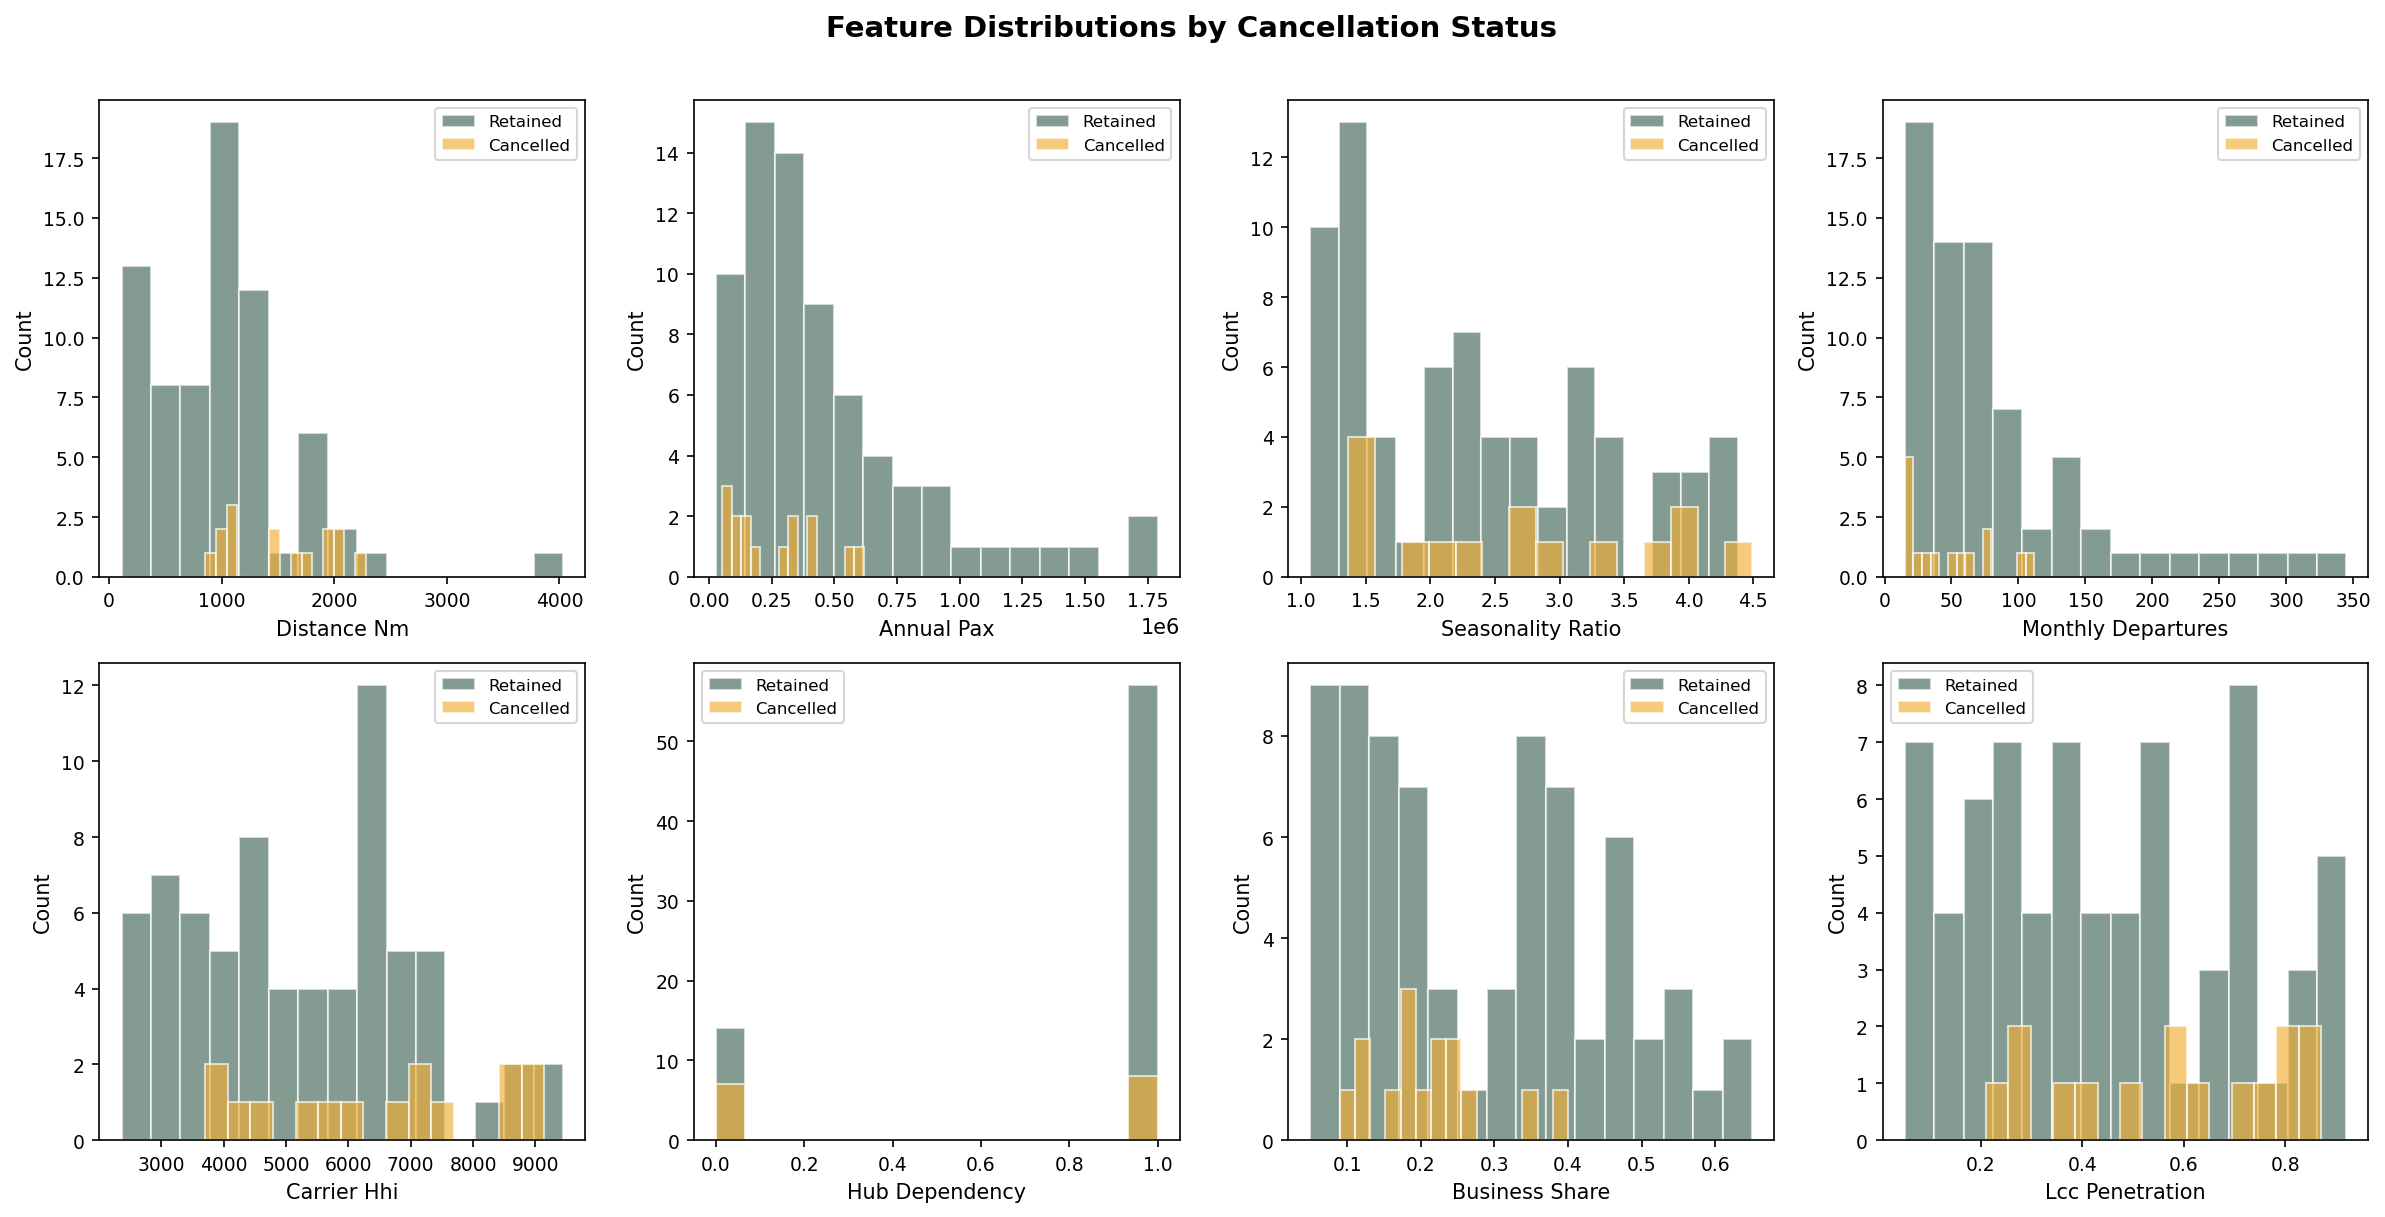

In [70]:
show_image('assets/feature_distributions-dev.png', width=900)

**Figure:** Histograms of the 8 clustering features, split by cancellation status (green = retained, gold = cancelled). Cancelled routes tend to appear in the lower passenger volume bins, higher seasonality ratios, higher carrier HHI (less competition), and lower hub dependency (value 0). They also lean toward higher LCC penetration and lower business share. These visual differences suggest the clustering algorithm will have genuine structural signal to work with.

### Feature Correlations

A correlation heatmap shows how features relate to each other. If two features are highly correlated, they carry redundant information and may skew the clustering toward that shared dimension. We want to see moderate correlations at most, so that each feature contributes distinct information.

In [71]:
# Correlation heatmap
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

cmap = sns.diverging_palette(220, 40, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'},
            ax=ax)

# Clean up axis labels
labels = [col.replace('_', ' ').title() for col in feature_cols]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(labels, rotation=0, fontsize=10)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('assets/feature_correlation-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: assets/feature_correlation-dev.png")

Saved: assets/feature_correlation-dev.png


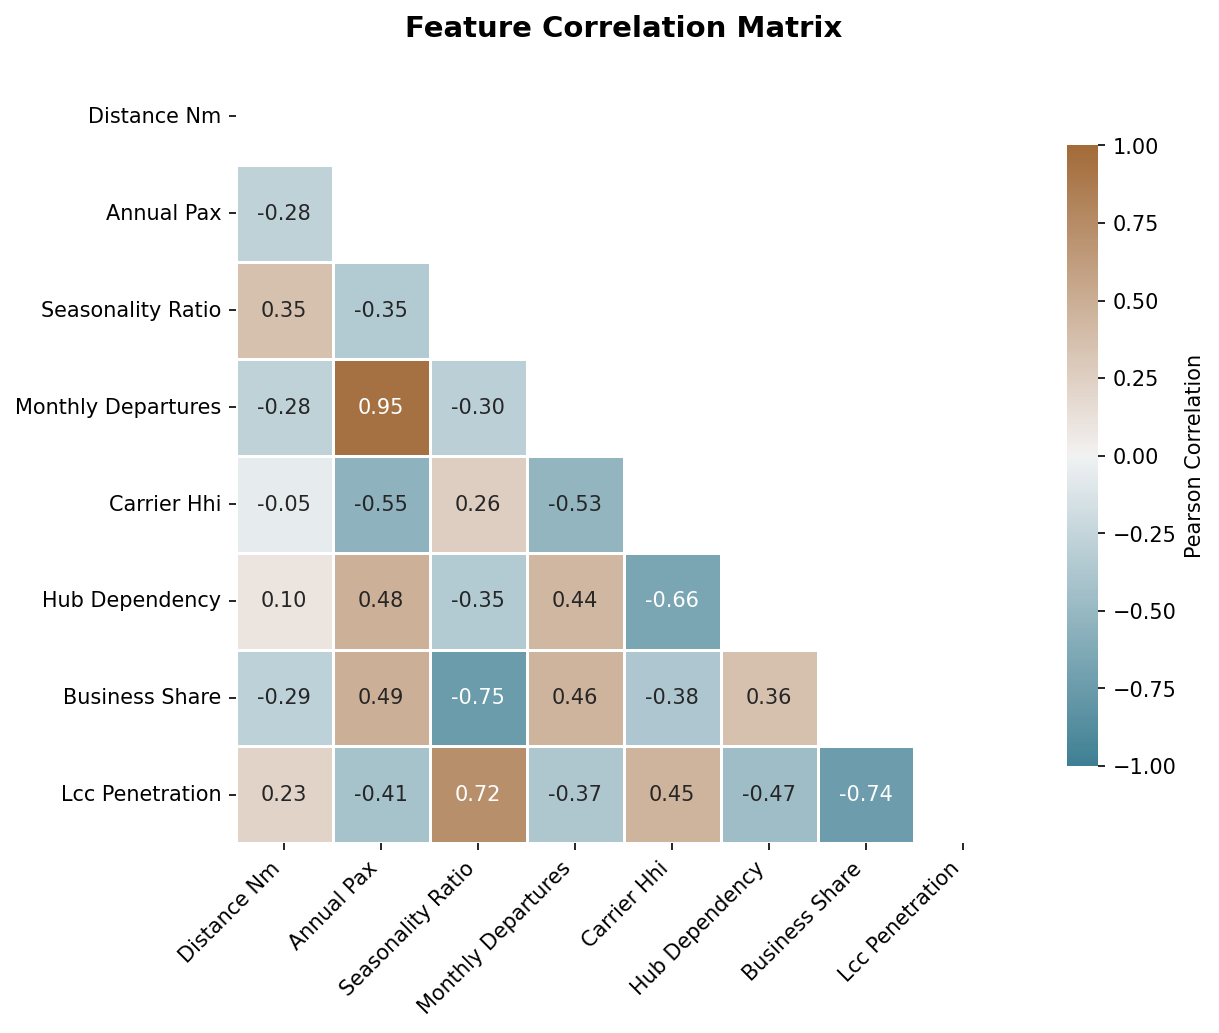

In [72]:
show_image('assets/feature_correlation-dev.png', width=700)

**Figure:** Pearson correlation matrix of the 8 clustering features (lower triangle only, since the matrix is symmetric). A few notable patterns:

- **Annual passengers and monthly departures** are nearly identical (r = 0.95). This makes sense because more passengers require more flights. They essentially measure the same thing: route size. We keep both for now because `StandardScaler` will normalize their scales, but be aware that the clustering will give extra weight to the "route size" dimension.
- **Seasonality, LCC penetration, and business share** form a correlated triangle. Leisure routes are seasonal, attract low-cost carriers, and have few business travelers. Business routes are the opposite. This is a real structural pattern in the data, not a problem.
- **Carrier HHI and hub dependency** are negatively correlated (r = -0.66). Hub routes attract multiple carriers, lowering concentration. Secondary routes tend toward monopolies.

No pair is so highly correlated that we need to drop features. The 0.95 between passengers and departures is the one to watch, but for this demo, retaining all 8 features keeps the analysis transparent.

### Imputation and Standardization

Clustering algorithms like K-Means calculate distances between data points. If one feature ranges from 15,000 to 2,000,000 (annual passengers) while another ranges from 0 to 1 (hub dependency), the larger feature will dominate the distance calculation and the smaller one will be effectively ignored [2].

**StandardScaler** fixes this by transforming each feature to have zero mean and unit variance:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ is the feature mean and $\sigma$ is the standard deviation. After scaling, all features contribute equally to the distance computation.

We also apply **median imputation** as a safety net. Our dataset has no missing values, but in production pipelines, missing data can appear without warning. Median imputation fills any gaps with the feature's median value, which is robust to outliers [2].

In [73]:
# Extract feature matrix
X_raw = df[feature_cols].values
print(f"Raw feature matrix shape: {X_raw.shape}")

# Step 1: Median imputation (safety net for missing values)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)
print(f"Values imputed: {np.isnan(X_raw).sum()} (expected 0)")

# Step 2: Standardize features to zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"\nScaled feature matrix shape: {X_scaled.shape}")
print(f"Mean of each feature after scaling (should be ~0):")
print(np.round(X_scaled.mean(axis=0), 6))
print(f"\nStd of each feature after scaling (should be ~1):")
print(np.round(X_scaled.std(axis=0), 4))

Raw feature matrix shape: (86, 8)
Values imputed: 0 (expected 0)

Scaled feature matrix shape: (86, 8)
Mean of each feature after scaling (should be ~0):
[-0.  0. -0. -0. -0. -0.  0. -0.]

Std of each feature after scaling (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1.]


In [74]:
# Quick comparison: raw vs scaled values for the first 5 routes
sample_raw = pd.DataFrame(X_raw[:5], columns=feature_cols).round(2)
sample_scaled = pd.DataFrame(X_scaled[:5], columns=feature_cols).round(2)

print("Raw values (first 5 routes):")
print(sample_raw.to_string(index=False))
print("\nScaled values (first 5 routes):")
print(sample_scaled.to_string(index=False))

Raw values (first 5 routes):
 distance_nm  annual_pax  seasonality_ratio  monthly_departures  carrier_hhi  hub_dependency  business_share  lcc_penetration
       318.0    9.22e+05               1.37               138.0       3295.0             1.0            0.53             0.10
      1887.0    1.87e+05               2.34                36.0       7235.0             1.0            0.33             0.22
      1959.0    5.22e+05               1.38                79.0       3415.0             1.0            0.65             0.24
       378.0    1.79e+06               1.22               289.0       3282.0             1.0            0.47             0.06
       643.0    1.03e+05               1.74                18.0       6234.0             1.0            0.32             0.35

Scaled values (first 5 routes):
 distance_nm  annual_pax  seasonality_ratio  monthly_departures  carrier_hhi  hub_dependency  business_share  lcc_penetration
       -1.20        1.34              -1.04             

Notice how the raw `annual_pax` values range from ~100,000 to ~1,790,000, but after scaling they range from about -0.87 to 3.69. Meanwhile, `business_share` (originally 0.32 to 0.65) now sits on a similar scale. The clustering algorithm will treat each feature with equal importance.

In [75]:
# Clean up temporary variables from data preparation
del X_raw, X_imputed, sample_raw, sample_scaled, corr_matrix
gc.collect()

print(f"Data preparation complete.")
print(f"  X_scaled shape: {X_scaled.shape} (ready for clustering)")
print(f"  Features: {feature_cols}")
print(f"  Scaler and imputer saved for later use if needed.")

Data preparation complete.
  X_scaled shape: (86, 8) (ready for clustering)
  Features: ['distance_nm', 'annual_pax', 'seasonality_ratio', 'monthly_departures', 'carrier_hhi', 'hub_dependency', 'business_share', 'lcc_penetration']
  Scaler and imputer saved for later use if needed.


## K-Means Clustering

Now we get to the core of this demo. We run K-Means clustering on the scaled features to discover natural groupings among the 91 transborder routes. The process has three steps:

1. **Search for the best k** by running K-Means for k = 2 through 8 and evaluating each with inertia (the elbow method) and silhouette score.
2. **Fit the final model** with the chosen k.
3. **Interpret the clusters** by examining their centroids and assigning human-readable archetype labels.

### Selecting the Optimal Number of Clusters

We do not know ahead of time how many natural groupings exist in the data. To find the right $k$, we run K-Means for $k = 2$ through $k = 8$ and track two metrics:

- **Inertia** (within-cluster sum of squares): measures how tight the clusters are. Lower is better, but it always decreases as $k$ increases. We look for an "elbow" where the rate of decrease slows sharply.
- **Silhouette score**: measures both cluster tightness and separation. Higher is better, with a clear peak indicating the most natural partition.

In [76]:
# Run K-Means for k = 2 through 8
k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(round(sil, 4))
    print(f"k={k}  |  Inertia: {km.inertia_:.1f}  |  Silhouette: {sil:.4f}")

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"\nBest silhouette score: {max(silhouette_scores):.4f} at k={best_k}")

k=2  |  Inertia: 449.1  |  Silhouette: 0.3074
k=3  |  Inertia: 318.4  |  Silhouette: 0.3364
k=4  |  Inertia: 217.1  |  Silhouette: 0.3824
k=5  |  Inertia: 193.1  |  Silhouette: 0.3416
k=6  |  Inertia: 173.9  |  Silhouette: 0.3089
k=7  |  Inertia: 159.3  |  Silhouette: 0.3057
k=8  |  Inertia: 146.3  |  Silhouette: 0.2389

Best silhouette score: 0.3824 at k=4


In [77]:
# Plot elbow curve and silhouette score side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {'maroon': '#8D4F58', 'green': '#426556', 'gold': '#F1AE35',
          'blue': '#1B587C', 'gray': '#555555'}

# Elbow curve (inertia)
ax1.plot(list(k_range), inertias, 'o-', color=colors['blue'], linewidth=2, markersize=8)
ax1.axvline(x=best_k, color=colors['gold'], linestyle='--', linewidth=1.5, alpha=0.8, label=f'Selected k={best_k}')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.set_xticks(list(k_range))
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Silhouette score
bars = ax2.bar(list(k_range), silhouette_scores, color=colors['gray'], edgecolor='white', width=0.6)
bars[np.argmax(silhouette_scores)].set_color(colors['green'])
ax2.axhline(y=max(silhouette_scores), color=colors['gold'], linestyle='--', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score by k', fontsize=14, fontweight='bold')
ax2.set_xticks(list(k_range))
ax2.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(silhouette_scores):
    weight = 'bold' if i == np.argmax(silhouette_scores) else 'normal'
    ax2.text(list(k_range)[i], v + 0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight=weight)

plt.tight_layout()
plt.savefig('assets/kmeans_elbow_silhouette-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: assets/kmeans_elbow_silhouette-dev.png")

Saved: assets/kmeans_elbow_silhouette-dev.png


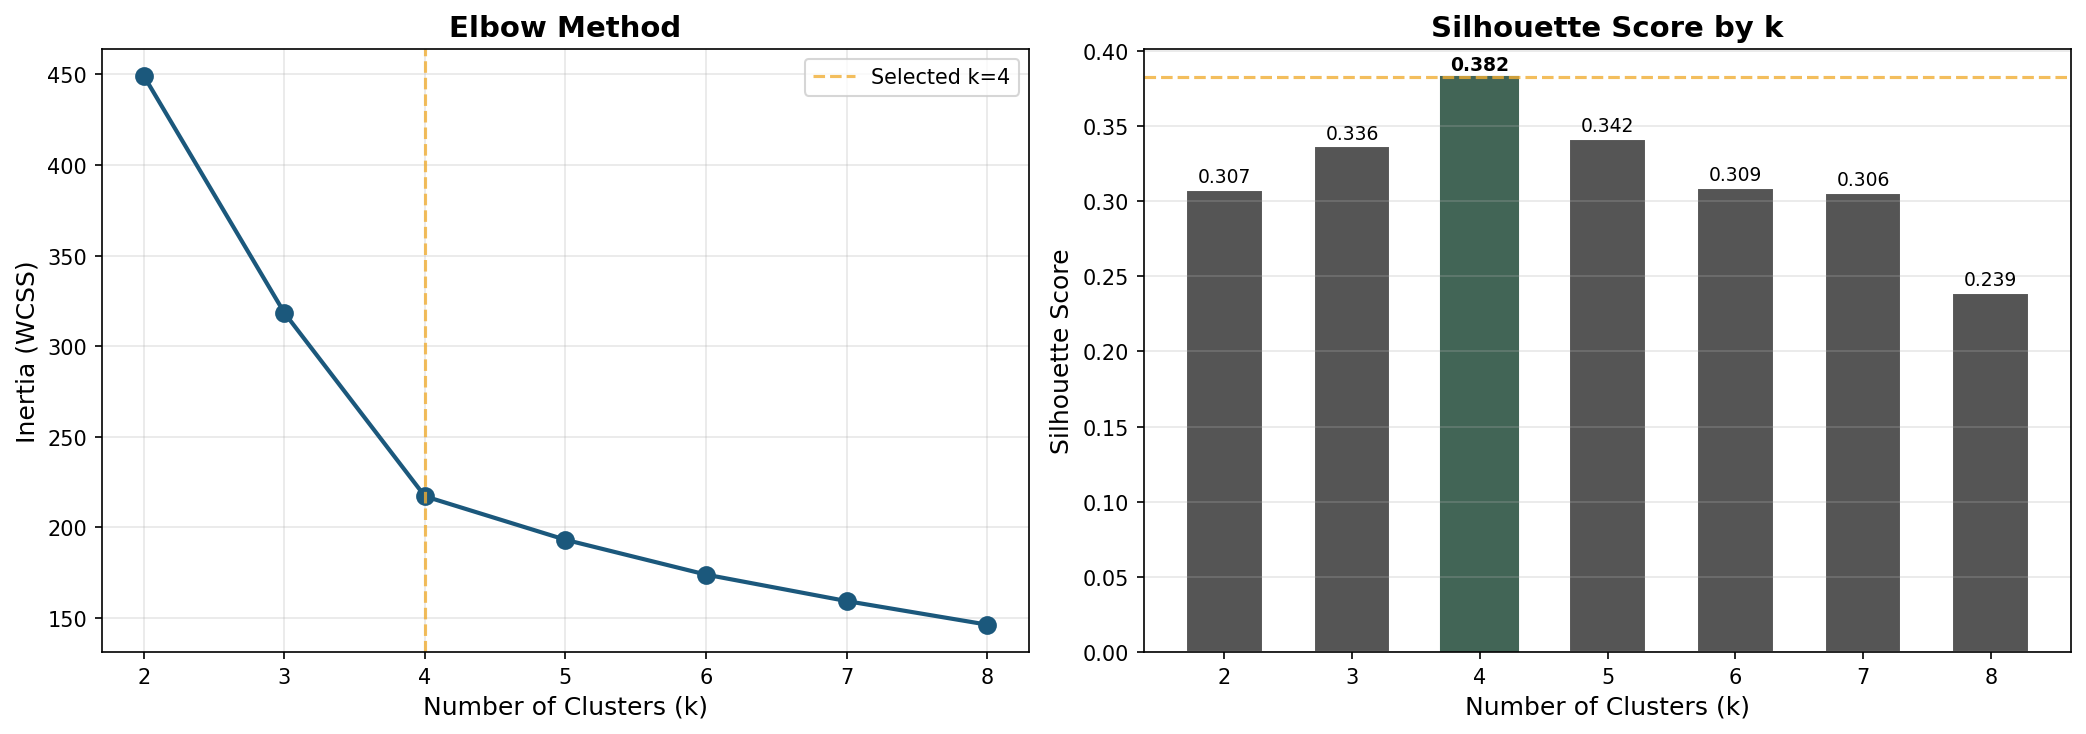

In [78]:
show_image('assets/kmeans_elbow_silhouette-dev.png', width=900)

**Figure:** Elbow method (left) and silhouette score (right) for K-Means clustering with k = 2 to 8. The elbow curve shows a clear bend at k = 4, where the rate of inertia decrease slows substantially. The silhouette score peaks at k = 4 with a score of 0.382, confirming that four clusters provide the most natural partition of the route data. Both metrics agree on k = 4 as the optimal choice.

### Fitting the Final K-Means Model

With k = 4 selected, we fit the final K-Means model. The algorithm partitions our 91 routes into 4 clusters by minimizing the within-cluster sum of squares. We use `n_init=10` (the default), which means the algorithm runs 10 times with different random initializations and keeps the best result. This reduces the risk of getting stuck in a poor local minimum [2].

In [79]:
# Fit final K-Means with k=4
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"K-Means fitted with k={best_k}")
print(f"Final inertia: {kmeans_final.inertia_:.1f}")
print(f"Silhouette score: {silhouette_score(X_scaled, df['kmeans_cluster']):.4f}")
print(f"\nCluster sizes:")
print(df['kmeans_cluster'].value_counts().sort_index().to_string())

K-Means fitted with k=4
Final inertia: 217.1
Silhouette score: 0.3824

Cluster sizes:
kmeans_cluster
0    13
1    21
2    28
3    24


### Interpreting the Clusters

The cluster centroids tell us the "average route" in each group. By examining the centroid values (in original scale, not standardized), we can assign a descriptive archetype label to each cluster. This is where the algorithm's output becomes actionable intelligence for network planners.

In [80]:
# Examine cluster centroids in original scale
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_original, columns=feature_cols)
centroid_df.index.name = 'Cluster'

print("Cluster centroids (original scale):")
centroid_df.round(2)

Cluster centroids (original scale):


,distance_nm,annual_pax,seasonality_ratio,monthly_departures,carrier_hhi,hub_dependency,business_share,lcc_penetration
Cluster,,,,,,,,
0,468.92,1.15e+06,1.31,210.85,3721.92,1.0,0.50,0.17
1,975.95,1.14e+05,3.00,25.81,7569.52,-0.0,0.17,0.67
2,1111.86,2.99e+05,1.69,52.18,5274.39,1.0,0.36,0.30
3,1485.79,4.53e+05,3.28,84.50,4761.33,1.0,0.12,0.65


In [81]:
# Assign archetype labels based on centroid analysis
# Cluster 0: short distance, very high pax, low seasonality, high business share, hub-based
# Cluster 1: medium distance, very low pax, high seasonality, non-hub, high HHI (monopoly)
# Cluster 2: medium-long distance, moderate pax, moderate seasonality, hub-based, mixed use
# Cluster 3: long distance, high pax, very high seasonality, hub-based, high LCC, low business

archetype_map = {
    0: 'Hub Business Corridors',
    1: 'Secondary Thin Routes',
    2: 'Hub Mixed Long-Haul',
    3: 'Hub Leisure Seasonal',
}

df['cluster_name'] = df['kmeans_cluster'].map(archetype_map)

# Print summary per cluster
for cluster_id, name in archetype_map.items():
    cluster_routes = df[df['kmeans_cluster'] == cluster_id]
    sample_routes = cluster_routes['route'].head(5).tolist()
    print(f"Cluster {cluster_id}: {name} ({len(cluster_routes)} routes)")
    print(f"  Sample routes: {', '.join(sample_routes)}")
    print()

Cluster 0: Hub Business Corridors (13 routes)
  Sample routes: YYZ-JFK, YYZ-ORD, YYZ-BOS, YYZ-DFW, YYZ-EWR

Cluster 1: Secondary Thin Routes (21 routes)
  Sample routes: YEG-LAS, YEG-PHX, YEG-LAX, YEG-SFO, YEG-MCO

Cluster 2: Hub Mixed Long-Haul (28 routes)
  Sample routes: YYZ-LAX, YYZ-SFO, YYZ-ATL, YYZ-MIA, YYZ-DEN

Cluster 3: Hub Leisure Seasonal (24 routes)
  Sample routes: YYZ-LAS, YYZ-MCO, YVR-PHX, YVR-LAS, YYC-PHX



The four clusters capture distinct route archetypes:

| Cluster | Archetype | Description |
|---------|-----------|-------------|
| 0 | **Hub Business Corridors** | Short-haul hub routes with very high passenger volumes, steady year-round demand, high business share, and strong carrier competition. Think YYZ-JFK or YYZ-ORD. |
| 1 | **Secondary Thin Routes** | Routes from smaller Canadian cities (Edmonton, Winnipeg, Kelowna) with low passenger volumes, high seasonality, near-monopoly carrier concentration, and high LCC penetration. |
| 2 | **Hub Mixed Long-Haul** | Longer hub routes with moderate traffic and a balanced mix of business and leisure demand. Moderate competition. Routes like YYZ-LAX or YVR-ORD. |
| 3 | **Hub Leisure Seasonal** | Long-distance hub routes to leisure destinations (Florida, Hawaii, Las Vegas) with very high seasonality, heavy LCC presence, and minimal business travel. |

These archetypes align well with how airline network planners think about route portfolios. The question now is: do WestJet's cancelled routes cluster disproportionately into one or two of these groups?

In [82]:
# Cluster summary with cancellation breakdown
cluster_summary = df.groupby(['kmeans_cluster', 'cluster_name']).agg(
    total_routes=('cancelled', 'count'),
    cancelled=('cancelled', 'sum'),
    avg_pax=('annual_pax', 'mean'),
    avg_seasonality=('seasonality_ratio', 'mean'),
    avg_hhi=('carrier_hhi', 'mean'),
    avg_biz_share=('business_share', 'mean'),
).reset_index()

cluster_summary['cancellation_rate_pct'] = (cluster_summary['cancelled'] / cluster_summary['total_routes'] * 100).round(1)
cluster_summary = cluster_summary.sort_values('cancellation_rate_pct', ascending=False)

print("CLUSTER SUMMARY WITH CANCELLATION RATES")
print(cluster_summary.to_string(index=False))

CLUSTER SUMMARY WITH CANCELLATION RATES
 kmeans_cluster           cluster_name  total_routes  cancelled  avg_pax  avg_seasonality  avg_hhi  avg_biz_share  cancellation_rate_pct
              1  Secondary Thin Routes            21          7 1.14e+05             3.00  7569.52           0.17                   33.3
              3   Hub Leisure Seasonal            24          4 4.53e+05             3.28  4761.33           0.12                   16.7
              2    Hub Mixed Long-Haul            28          4 2.99e+05             1.69  5274.39           0.36                   14.3
              0 Hub Business Corridors            13          0 1.15e+06             1.31  3721.92           0.50                    0.0


In [83]:
# Visualize cluster sizes and cancellation rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_palette = {'maroon': '#8D4F58', 'green': '#426556', 'gold': '#F1AE35',
                  'blue': '#1B587C', 'gray': '#555555'}
cluster_colors = [colors_palette['blue'], colors_palette['maroon'],
                  colors_palette['green'], colors_palette['gold']]

# Sort by cluster ID for consistent ordering
summary_sorted = cluster_summary.sort_values('kmeans_cluster')

# Cluster sizes (stacked: cancelled vs retained)
retained = summary_sorted['total_routes'] - summary_sorted['cancelled']
x_pos = range(len(summary_sorted))
short_names = ['Hub Business\nCorridors', 'Secondary\nThin Routes',
               'Hub Mixed\nLong-Haul', 'Hub Leisure\nSeasonal']

bars_r = ax1.bar(x_pos, retained.values, color=[cluster_colors[i] for i in summary_sorted['kmeans_cluster']],
                 edgecolor='white', label='Retained', alpha=0.7)
bars_c = ax1.bar(x_pos, summary_sorted['cancelled'].values, bottom=retained.values,
                 color=[cluster_colors[i] for i in summary_sorted['kmeans_cluster']],
                 edgecolor='white', label='Cancelled', hatch='///', alpha=0.95)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(short_names, fontsize=9)
ax1.set_ylabel('Number of Routes', fontsize=12)
ax1.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

for i, (r, c) in enumerate(zip(retained.values, summary_sorted['cancelled'].values)):
    ax1.text(i, r + c + 0.3, f'{int(r + c)}', ha='center', fontsize=10, fontweight='bold')

# Cancellation rates (ordered from worst to best)
summary_by_rate = cluster_summary.sort_values('cancellation_rate_pct', ascending=True)
y_pos = range(len(summary_by_rate))
bar_colors = [cluster_colors[c] for c in summary_by_rate['kmeans_cluster']]

bars = ax2.barh(y_pos, summary_by_rate['cancellation_rate_pct'].values,
                color=bar_colors, edgecolor='white', height=0.6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(summary_by_rate['cluster_name'].values, fontsize=10)
ax2.set_xlabel('Cancellation Rate (%)', fontsize=12)
ax2.set_title('Cancellation Rate by Cluster', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

for i, v in enumerate(summary_by_rate['cancellation_rate_pct'].values):
    weight = 'bold' if v == summary_by_rate['cancellation_rate_pct'].max() else 'normal'
    ax2.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight=weight)

plt.tight_layout()
plt.savefig('assets/kmeans_cluster_summary-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: assets/kmeans_cluster_summary-dev.png")

Saved: assets/kmeans_cluster_summary-dev.png


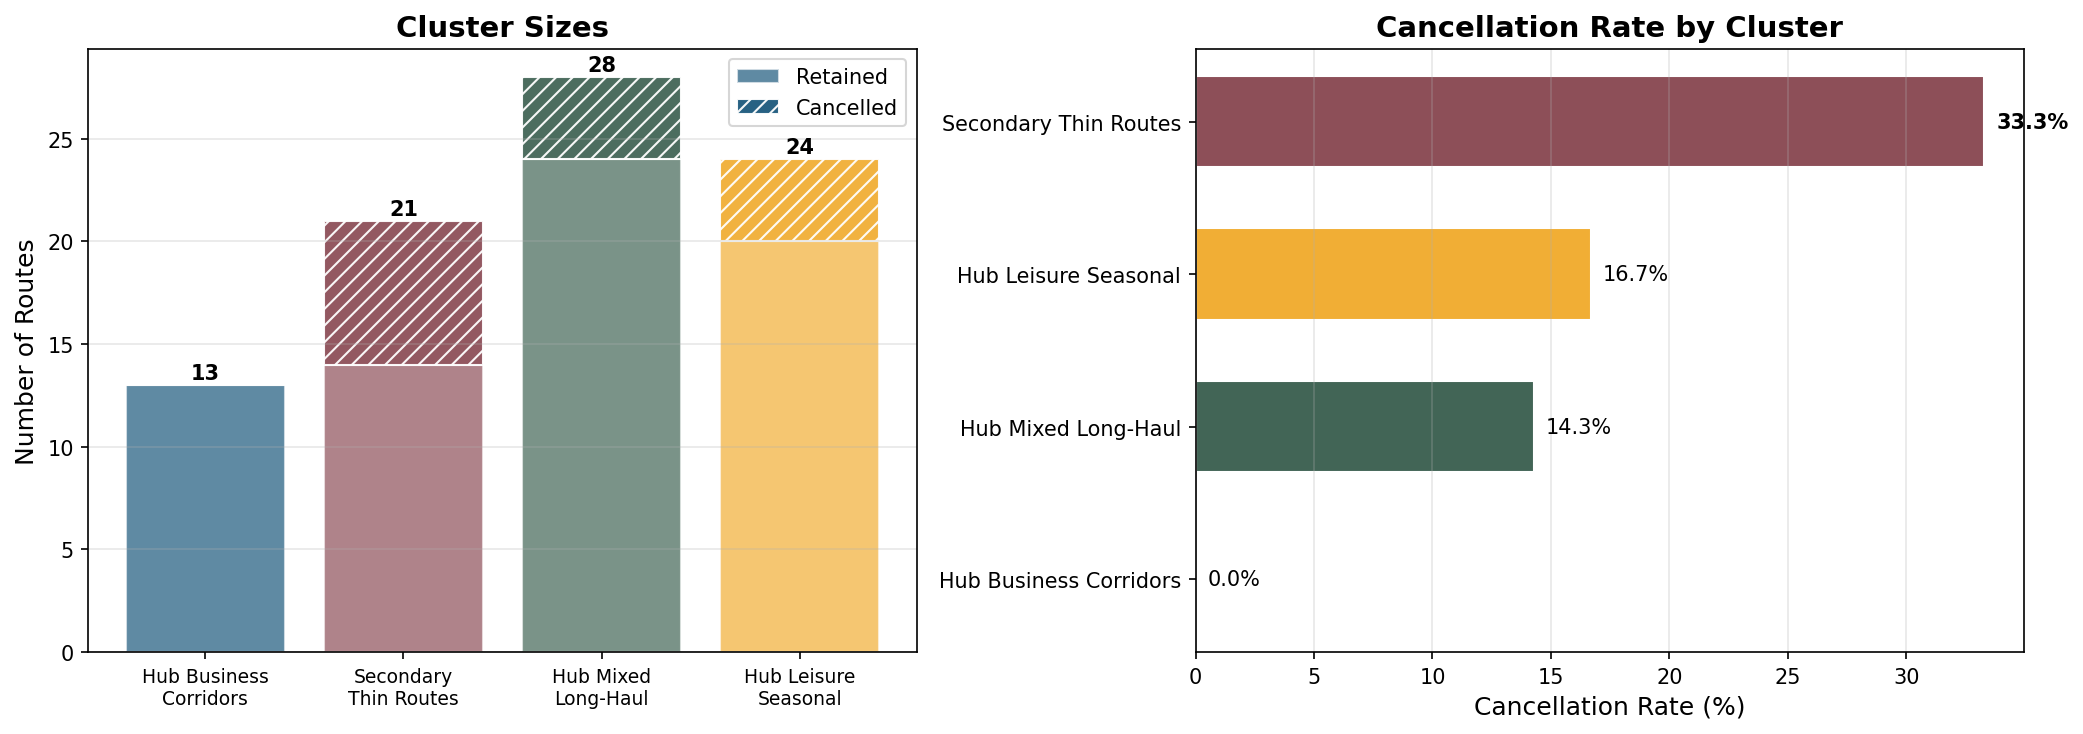

In [84]:
show_image('assets/kmeans_cluster_summary-dev.png', width=900)

**Figure:** K-Means cluster sizes (left) and cancellation rates (right). The hatched portions in the left chart represent cancelled routes. Secondary Thin Routes have the highest cancellation rate at 33.3%, with 7 of 21 routes cancelled. Hub Leisure Seasonal and Hub Mixed Long-Haul show moderate cancellation rates (16.7% and 14.3%). Hub Business Corridors have zero cancellations. The pattern is clear: routes from smaller cities with thin traffic, high seasonality, and single-carrier dependency are the most vulnerable to demand shocks.

In [85]:
# Clean up temporary variables from K-Means section
del k_range, inertias, silhouette_scores, km, labels, sil
del centroids_scaled, centroids_original, centroid_df
del cluster_summary, summary_sorted, summary_by_rate
del retained, bars_r, bars_c, bars, bar_colors, x_pos, y_pos, short_names
del fig, ax1, ax2, colors_palette, cluster_colors
gc.collect()

print(f"K-Means clustering complete.")
print(f"  Optimal k: {best_k}")
print(f"  Model: kmeans_final (saved for later comparison)")
print(f"  Columns added to df: 'kmeans_cluster', 'cluster_name'")

K-Means clustering complete.
  Optimal k: 4
  Model: kmeans_final (saved for later comparison)
  Columns added to df: 'kmeans_cluster', 'cluster_name'


## Hierarchical Clustering

K-Means gave us a useful partition, but it has a limitation: it requires choosing k upfront and produces flat (non-nested) clusters. **Agglomerative hierarchical clustering** takes a different approach. It starts with each data point as its own cluster, then repeatedly merges the two closest clusters until only one remains [2]. The result is a tree-like structure called a **dendrogram** that shows how routes relate to each other at every level of granularity.

The merging strategy matters. We use **Ward's linkage**, which merges the pair of clusters that causes the smallest increase in total within-cluster variance. Ward's linkage tends to produce compact, similarly-sized clusters and works well with Euclidean distances [3]. It is equivalent to minimizing the same objective function as K-Means (within-cluster sum of squares), just through a different algorithmic path.

The dendrogram is the main advantage of hierarchical clustering. It lets us visually inspect whether the data has a clear hierarchical structure and choose the number of clusters by "cutting" the tree at a specific height. If K-Means and hierarchical clustering agree on the groupings, that is strong evidence the clusters are real and not artifacts of one algorithm's assumptions.

### Computing the Linkage Matrix

The first step is to compute the **linkage matrix**, which encodes the full merge history. Each row records which two clusters were merged, at what distance, and how many data points the resulting cluster contains. We use `scipy.cluster.hierarchy.linkage` with Ward's method on the same standardized features we used for K-Means.

In [86]:
# Compute Ward's linkage matrix
Z = linkage(X_scaled, method='ward', metric='euclidean')

print(f"Linkage matrix shape: {Z.shape}")
print(f"Number of merges: {Z.shape[0]} (expected {X_scaled.shape[0] - 1})")
print(f"\nFirst 5 merges (smallest distances):")
print(f"{'Cluster A':>10} {'Cluster B':>10} {'Distance':>10} {'Size':>6}")
for i in range(5):
    print(f"{int(Z[i, 0]):>10} {int(Z[i, 1]):>10} {Z[i, 2]:>10.4f} {int(Z[i, 3]):>6}")
print(f"\nLast 3 merges (largest distances):")
for i in range(-3, 0):
    print(f"{int(Z[i, 0]):>10} {int(Z[i, 1]):>10} {Z[i, 2]:>10.4f} {int(Z[i, 3]):>6}")

Linkage matrix shape: (85, 4)
Number of merges: 85 (expected 85)

First 5 merges (smallest distances):
 Cluster A  Cluster B   Distance   Size
        75         78     0.4659      2
        76         84     0.4956      2
         1         56     0.5690      2
        21         23     0.5818      2
        67         85     0.6003      2

Last 3 merges (largest distances):
       163        166    12.9199     47
       164        168    16.1421     68
       167        169    21.7642     86


### The Dendrogram

The dendrogram reads from bottom to top. Each leaf at the bottom is one route. The vertical lines show which routes (or groups of routes) get merged at each step, and the height of the horizontal bar connecting them represents the merge distance. Low merges mean the routes are very similar. Tall merges mean the groups being joined are quite different.

We draw a horizontal dashed line at the height where cutting the tree yields the same number of clusters we found optimal with K-Means (k = 4). If the line falls in a clear gap (where no merges happen for a while), it confirms that four clusters is a natural choice.

In [87]:
# Find the cut height for k=4 clusters
# With k clusters, the cut goes between the (k-1)th and k-th last merge distances
merge_distances = Z[:, 2]
cut_height = (merge_distances[-best_k] + merge_distances[-(best_k - 1)]) / 2

print(f"Merge distances for the last {best_k + 1} merges:")
for i in range(best_k + 1):
    print(f"  Merge {Z.shape[0] - best_k + i}: distance = {merge_distances[-(best_k + 1 - i)]:.4f}")
print(f"\nCut height for k={best_k}: {cut_height:.4f}")
print(f"  (midpoint between merge {Z.shape[0] - best_k} and merge {Z.shape[0] - best_k + 1})")

Merge distances for the last 5 merges:
  Merge 81: distance = 6.7252
  Merge 82: distance = 8.9608
  Merge 83: distance = 12.9199
  Merge 84: distance = 16.1421
  Merge 85: distance = 21.7642

Cut height for k=4: 10.9403
  (midpoint between merge 81 and merge 82)


In [88]:
# Plot the dendrogram
fig, ax = plt.subplots(figsize=(16, 7))

colors = {'maroon': '#8D4F58', 'green': '#426556', 'gold': '#F1AE35',
          'blue': '#1B587C', 'gray': '#555555'}

# Use route names as labels
route_labels = df['route'].values

dendro = dendrogram(
    Z,
    labels=route_labels,
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=cut_height,
    above_threshold_color=colors['gray'],
    ax=ax
)

# Draw the cut line
ax.axhline(y=cut_height, color=colors['gold'], linestyle='--', linewidth=2,
           label=f'Cut at k={best_k} (height={cut_height:.1f})')

ax.set_xlabel('Route', fontsize=12)
ax.set_ylabel('Ward Linkage Distance', fontsize=12)
ax.set_title("Hierarchical Clustering Dendrogram (Ward's Linkage)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('assets/hierarchical_dendrogram-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: assets/hierarchical_dendrogram-dev.png")

Saved: assets/hierarchical_dendrogram-dev.png


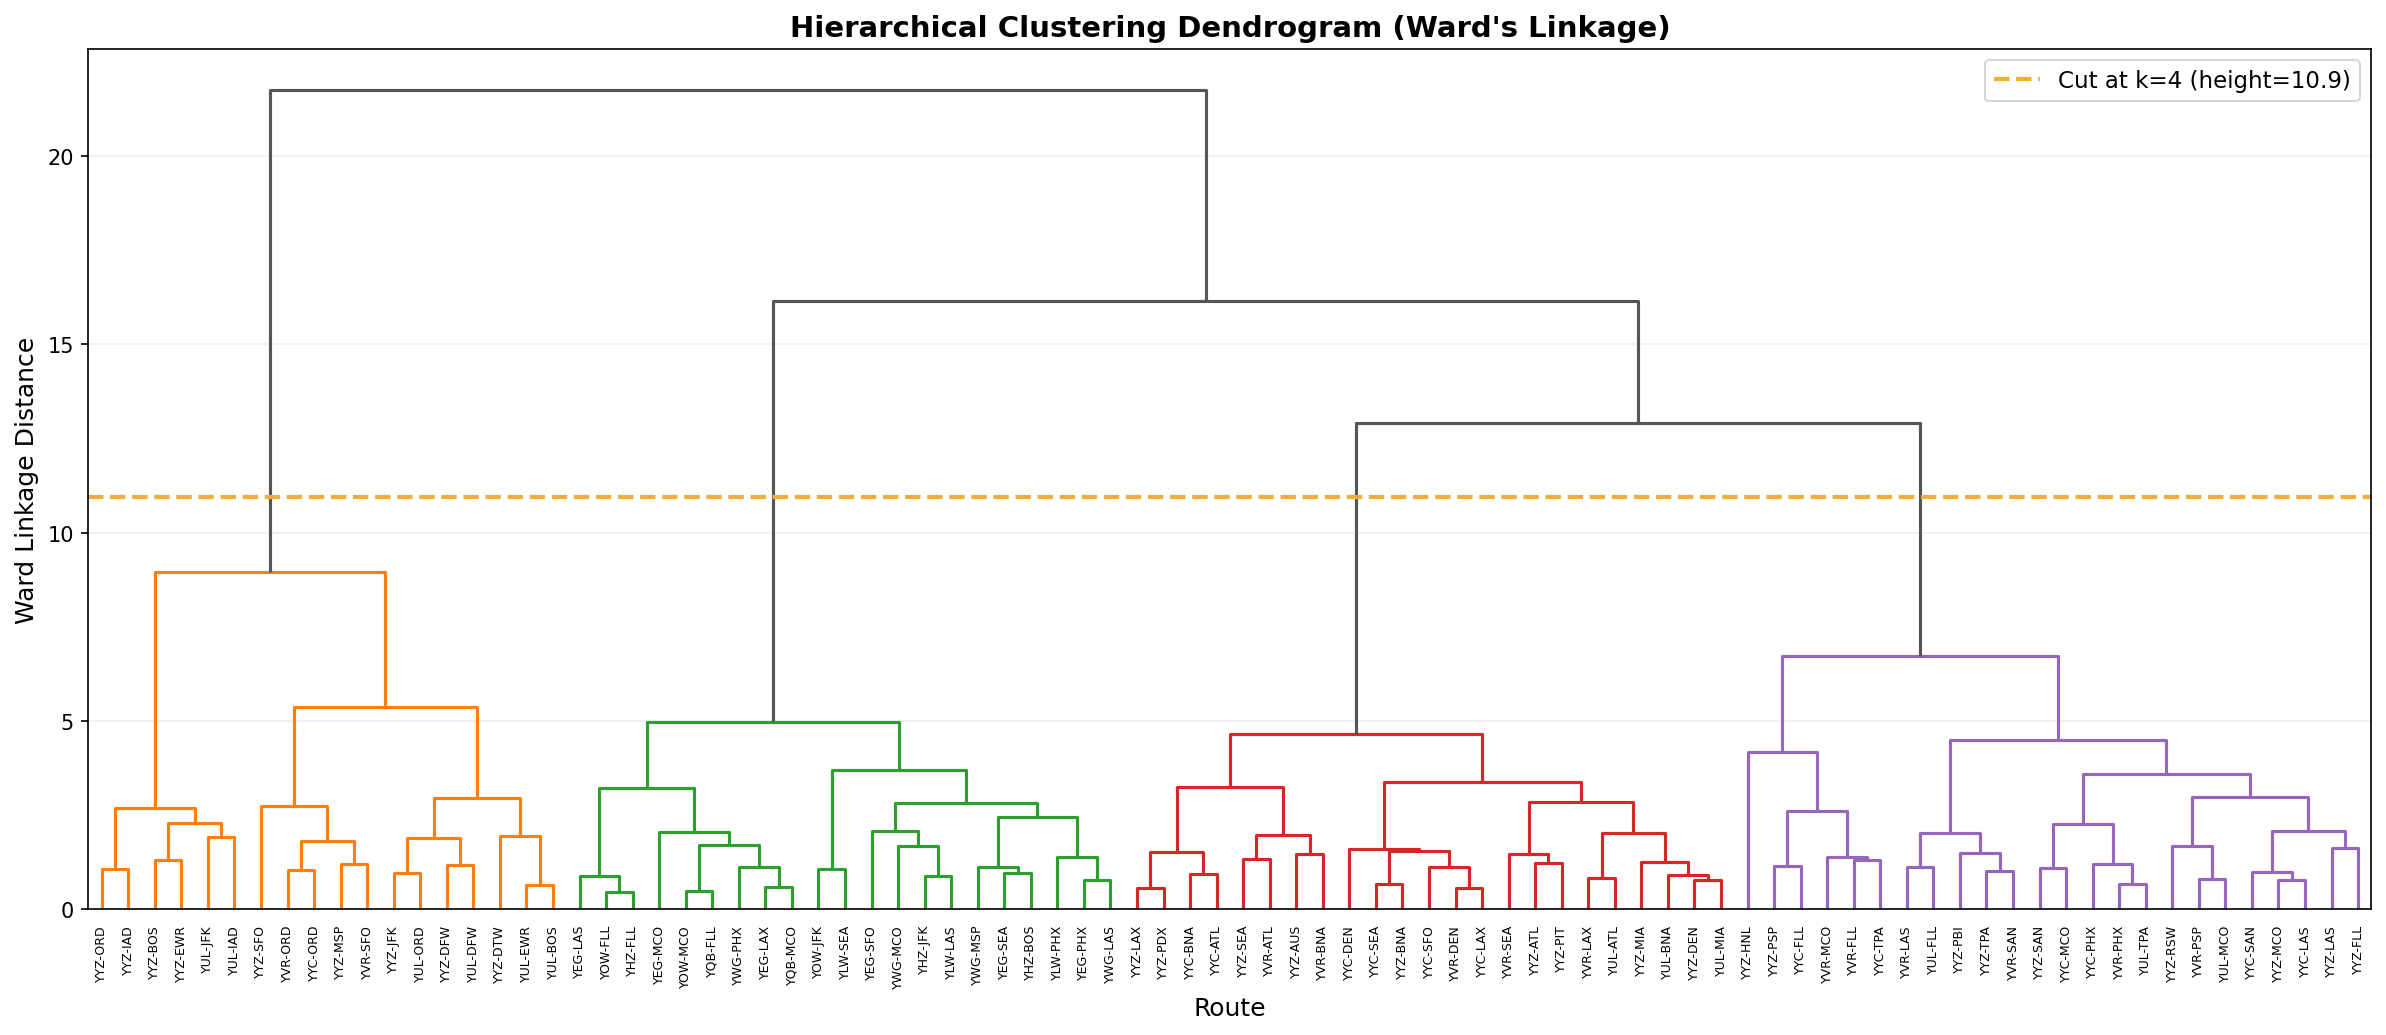

In [89]:
show_image('assets/hierarchical_dendrogram-dev.png', width=900)

**Figure:** Dendrogram from Ward's linkage hierarchical clustering of the 86 transborder routes. Each leaf at the bottom is one route. The gold dashed line marks the cut height (10.9) that produces 4 clusters. The four color-coded branches below the cut line correspond to distinct route groups. Notice the large vertical gap between the last 4-cluster merge (~9.0) and the next merge (~12.9). That gap confirms 4 clusters is a natural choice: the algorithm would need a big jump in distance to merge any further, meaning the four groups are genuinely different from each other.

### Assigning Hierarchical Cluster Labels

Now we cut the dendrogram at k = 4 using `AgglomerativeClustering` from scikit-learn. This gives us a flat cluster assignment for each route, just like K-Means did. We can then directly compare the two sets of labels.

In [90]:
# Fit agglomerative clustering with Ward's linkage
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['hier_cluster'] = agg.fit_predict(X_scaled)

print(f"Agglomerative clustering fitted with k={best_k}")
print(f"Silhouette score: {silhouette_score(X_scaled, df['hier_cluster']):.4f}")
print(f"\nHierarchical cluster sizes:")
print(df['hier_cluster'].value_counts().sort_index().to_string())

Agglomerative clustering fitted with k=4
Silhouette score: 0.3435

Hierarchical cluster sizes:
hier_cluster
0    18
1    24
2    21
3    23


### Comparing K-Means and Hierarchical Clustering

Two different algorithms produced two sets of cluster labels. How similar are they? The **Adjusted Rand Index (ARI)** measures the agreement between two clusterings, adjusted for chance [2]. It ranges from -1 (worse than random) to 1 (perfect agreement), with 0 meaning the agreement is no better than what random label assignment would produce.

$$\text{ARI} = \frac{\text{RI} - \mathbb{E}[\text{RI}]}{\max(\text{RI}) - \mathbb{E}[\text{RI}]}$$

where RI is the Rand Index (fraction of pairs that are correctly grouped together or correctly separated). An ARI above 0.65 is generally considered strong agreement [4].

We also build a cross-tabulation to see exactly how routes move between K-Means and hierarchical clusters.

In [91]:
# Compute Adjusted Rand Index
ari = adjusted_rand_score(df['kmeans_cluster'], df['hier_cluster'])
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

if ari > 0.65:
    print("Strong agreement between the two clustering methods.")
elif ari > 0.25:
    print("Moderate agreement between the two clustering methods.")
else:
    print("Weak agreement between the two clustering methods.")

Adjusted Rand Index (ARI): 0.8690
Strong agreement between the two clustering methods.


In [92]:
# Cross-tabulation: K-Means vs hierarchical cluster labels
cross_tab = pd.crosstab(
    df['kmeans_cluster'].map(archetype_map),
    df['hier_cluster'],
    margins=True,
    margins_name='Total'
)
cross_tab.index.name = 'K-Means Cluster'
cross_tab.columns.name = 'Hierarchical Cluster'

print("CROSS-TABULATION: K-Means vs Hierarchical Assignments\n")
print(cross_tab.to_string())

CROSS-TABULATION: K-Means vs Hierarchical Assignments

Hierarchical Cluster     0   1   2   3  Total
K-Means Cluster                              
Hub Business Corridors  13   0   0   0     13
Hub Leisure Seasonal     0  24   0   0     24
Hub Mixed Long-Haul      5   0   0  23     28
Secondary Thin Routes    0   0  21   0     21
Total                   18  24  21  23     86


In [93]:
# Visualize the comparison: agreement heatmap and silhouette comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {'maroon': '#8D4F58', 'green': '#426556', 'gold': '#F1AE35',
          'blue': '#1B587C', 'gray': '#555555'}

# Agreement heatmap (cross-tabulation without margins)
cross_tab_core = pd.crosstab(
    df['kmeans_cluster'].map(archetype_map),
    df['hier_cluster']
)
cross_tab_core.columns.name = 'Hierarchical Cluster'
cross_tab_core.index.name = 'K-Means Cluster'

sns.heatmap(cross_tab_core, annot=True, fmt='d', cmap='YlOrBr',
            linewidths=0.5, ax=ax1, cbar_kws={'label': 'Route Count'})
ax1.set_title('Cluster Assignment Agreement', fontsize=14, fontweight='bold')
ax1.set_ylabel('K-Means Cluster', fontsize=11)
ax1.set_xlabel('Hierarchical Cluster', fontsize=11)
ax1.tick_params(labelsize=9)

# Silhouette score comparison
methods = ['K-Means', 'Hierarchical']
sil_kmeans = silhouette_score(X_scaled, df['kmeans_cluster'])
sil_hier = silhouette_score(X_scaled, df['hier_cluster'])
sil_scores = [sil_kmeans, sil_hier]
bar_colors = [colors['blue'], colors['maroon']]

bars = ax2.bar(methods, sil_scores, color=bar_colors, edgecolor='white', width=0.5)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, max(sil_scores) * 1.3)

for i, v in enumerate(sil_scores):
    weight = 'bold' if v == max(sil_scores) else 'normal'
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=12, fontweight=weight)

# Add ARI annotation
ax2.text(0.5, max(sil_scores) * 1.15, f'ARI = {ari:.4f}',
         ha='center', fontsize=13, fontweight='bold', color=colors['green'],
         transform=ax2.get_xaxis_transform())

plt.tight_layout()
plt.savefig('assets/clustering_comparison-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: assets/clustering_comparison-dev.png")

Saved: assets/clustering_comparison-dev.png


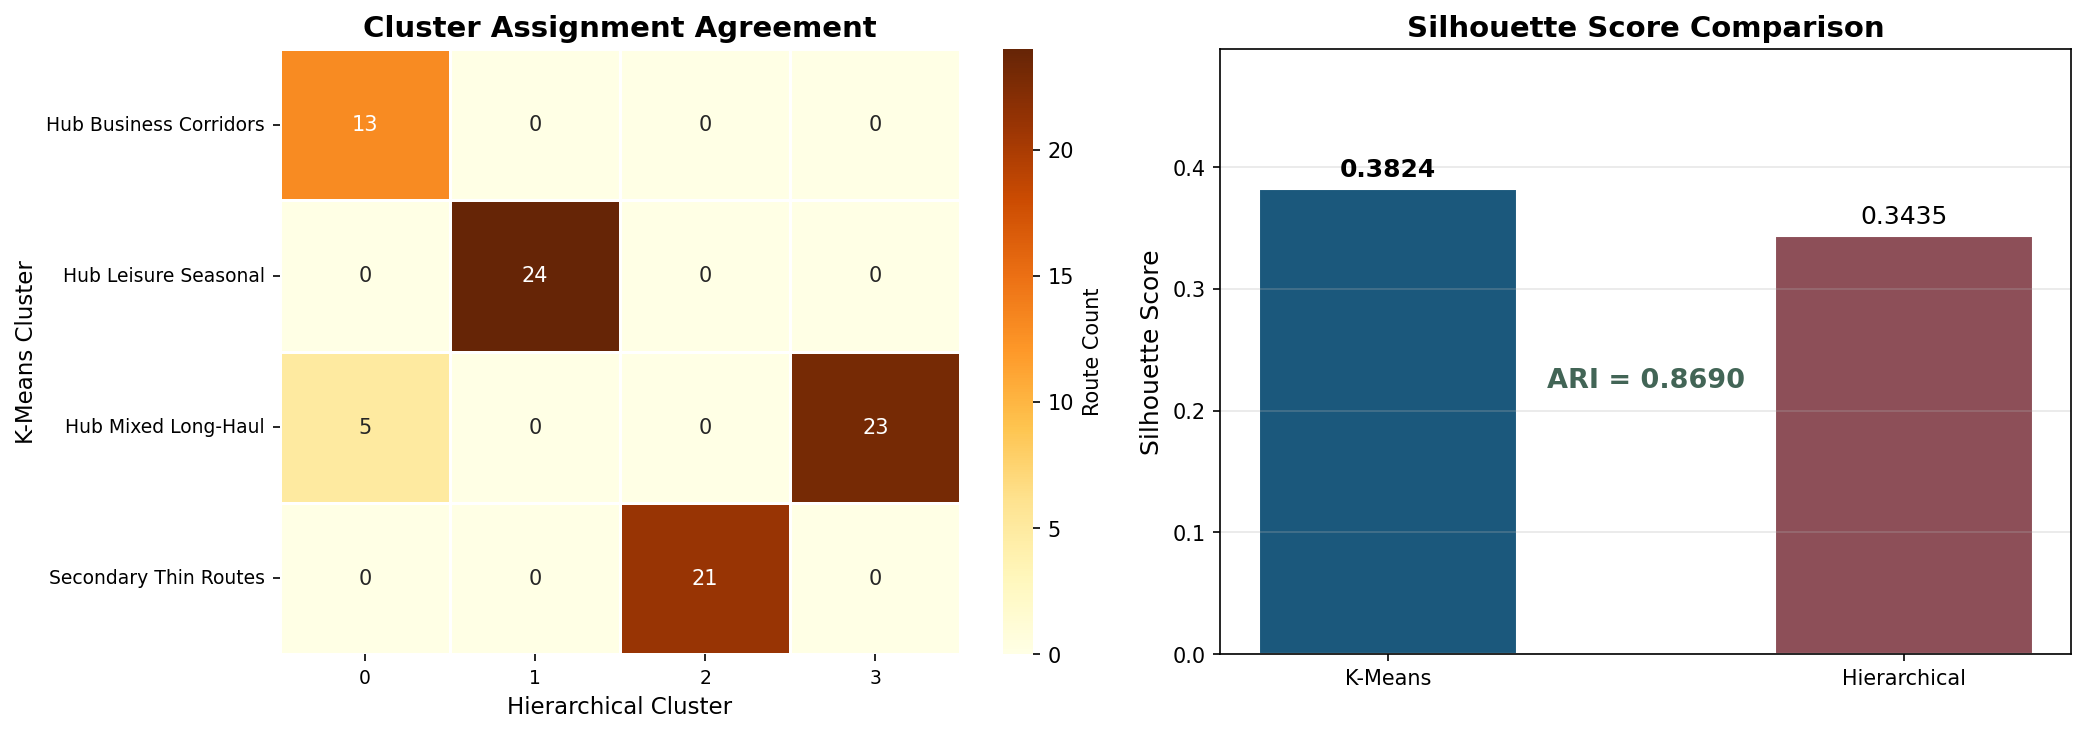

In [94]:
show_image('assets/clustering_comparison-dev.png', width=900)

**Figure:** Left: heatmap of the cross-tabulation between K-Means and hierarchical cluster assignments. Dark cells on the diagonal indicate strong agreement. Three of the four K-Means clusters map almost perfectly to a single hierarchical cluster: Hub Business Corridors (13 routes), Hub Leisure Seasonal (24 routes), and Secondary Thin Routes (21 routes). The only disagreement is that 5 routes from K-Means's Hub Mixed Long-Haul group get absorbed into hierarchical cluster 0 (alongside the Hub Business Corridors). Right: silhouette score comparison. K-Means achieves a slightly higher silhouette (0.3824 vs 0.3435), which is expected since K-Means directly optimizes cluster compactness. The ARI of 0.8690 confirms strong agreement between the two methods.

### Observations

The two algorithms agree on the broad structure. Three out of four clusters are nearly identical across methods. The small disagreement involves 5 routes at the boundary between Hub Business Corridors and Hub Mixed Long-Haul. These are longer hub routes with moderate business traffic that could plausibly belong to either group. Hierarchical clustering places them with the business corridors (emphasizing the hub endpoint), while K-Means separates them out (emphasizing the longer distance and lower passenger volume).

This level of agreement (ARI = 0.87) tells us something important: the 4-cluster structure is not an artifact of K-Means's assumptions. It is a genuine pattern in the data that a fundamentally different algorithm also recovers. For the rest of the analysis, we will use the K-Means labels because K-Means produced the higher silhouette score. But the hierarchical labels are saved in the dataset for anyone who wants to explore the boundary cases further.

In [95]:
# Clean up temporary variables from hierarchical clustering section
del Z, merge_distances, cut_height, dendro, route_labels
del agg, ari, cross_tab, cross_tab_core
del sil_kmeans, sil_hier, sil_scores, methods, bar_colors, bars
del fig, ax, ax1, ax2, colors
gc.collect()

print(f"Hierarchical clustering complete.")
print(f"  Columns added to df: 'hier_cluster'")
print(f"  K-Means labels retained as primary clustering (higher silhouette)")
print(f"  ARI between methods: 0.8690 (strong agreement)")

Hierarchical clustering complete.
  Columns added to df: 'hier_cluster'
  K-Means labels retained as primary clustering (higher silhouette)
  ARI between methods: 0.8690 (strong agreement)


## UMAP Visualization

We now have two sets of cluster labels (K-Means and hierarchical) for our 86 routes, each described by 8 features. But you cannot look at an 8-dimensional space directly. We need to project it down to 2D for visual inspection.

**UMAP** (Uniform Manifold Approximation and Projection) does this by constructing a weighted graph of nearest neighbors in the high-dimensional space and then optimizing a 2D layout that preserves the local neighborhood structure [5]. Points that were close in 8D will remain close in 2D. Unlike PCA, which only captures linear variance, UMAP can preserve non-linear relationships and tends to keep clusters visually separated.

We use three parameters:
- `n_neighbors=15`: controls how many nearby points UMAP considers when building the neighborhood graph. Smaller values preserve more local detail; larger values emphasize global structure.
- `min_dist=0.1`: controls how tightly UMAP packs points together. Lower values produce tighter clumps.
- `metric='euclidean'`: the distance measure in the original space, same as what K-Means used.

UMAP is used **only for visualization**. The clustering was done on the full 8-dimensional features. The 2D projection just lets us see the result.

### Projecting Routes to 2D

We fit UMAP on the same standardized feature matrix (`X_scaled`) used for clustering. The output is a 2D array where each row is a route's position on the 2D map.

In [96]:
# Apply UMAP to project 8D features to 2D
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42
)

umap_embedding = reducer.fit_transform(X_scaled)

# Add UMAP coordinates to the dataframe
df['umap_x'] = umap_embedding[:, 0]
df['umap_y'] = umap_embedding[:, 1]

print(f"UMAP embedding shape: {umap_embedding.shape}")
print(f"UMAP x range: [{umap_embedding[:, 0].min():.2f}, {umap_embedding[:, 0].max():.2f}]")
print(f"UMAP y range: [{umap_embedding[:, 1].min():.2f}, {umap_embedding[:, 1].max():.2f}]")

UMAP embedding shape: (86, 2)
UMAP x range: [-5.49, 17.78]
UMAP y range: [-4.95, 7.16]


### Cluster Map

The scatter plot below shows every route positioned by UMAP, colored by its K-Means cluster assignment. Routes that the algorithm grouped together should appear as visible clumps. We label a few notable routes so you can orient yourself on the map.

In [97]:
# UMAP scatter plot colored by K-Means cluster
fig, ax = plt.subplots(figsize=(12, 8))

colors = {'maroon': '#8D4F58', 'green': '#426556', 'gold': '#F1AE35',
          'blue': '#1B587C', 'gray': '#555555'}
cluster_colors = {
    0: colors['blue'],    # Hub Business Corridors
    1: colors['maroon'],  # Secondary Thin Routes
    2: colors['green'],   # Hub Mixed Long-Haul
    3: colors['gold'],    # Hub Leisure Seasonal
}

# Plot each cluster
for cluster_id, name in archetype_map.items():
    mask = df['kmeans_cluster'] == cluster_id
    ax.scatter(
        df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
        c=cluster_colors[cluster_id], label=name,
        s=60, alpha=0.75, edgecolors='white', linewidth=0.5
    )

# Label notable routes
notable_routes = ['YYZ-JFK', 'YVR-SFO', 'YYC-LAX', 'YYZ-MIA', 'YYZ-HNL',
                  'YEG-LAS', 'YWG-MCO', 'YUL-JFK', 'YYC-BNA', 'YLW-PHX']
for _, row in df[df['route'].isin(notable_routes)].iterrows():
    ax.annotate(
        row['route'], (row['umap_x'], row['umap_y']),
        fontsize=8, fontweight='bold',
        xytext=(6, 6), textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray'),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
    )

ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)
ax.set_title('Canada-U.S. Transborder Routes: UMAP Projection by Cluster', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('assets/umap_clusters-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: assets/umap_clusters-dev.png")

Saved: assets/umap_clusters-dev.png


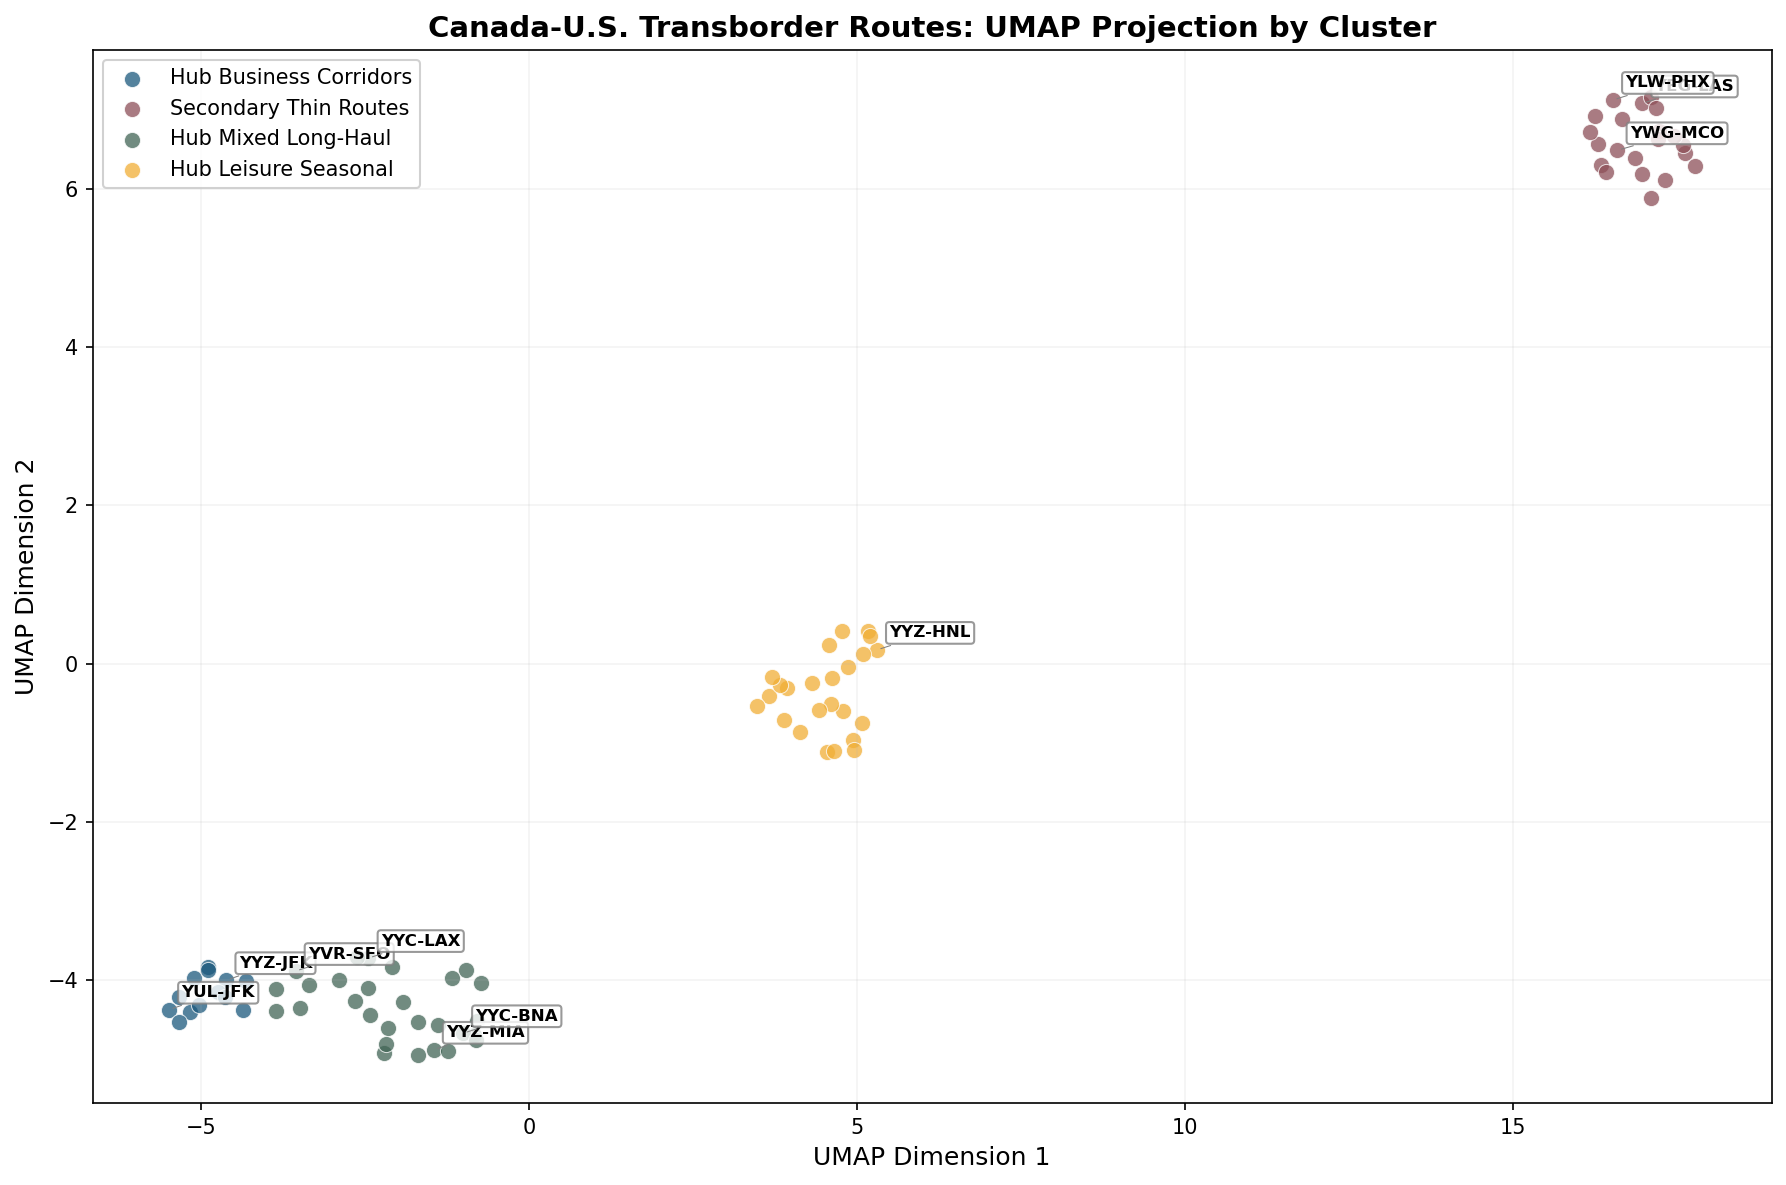

In [98]:
show_image('assets/umap_clusters-dev.png', width=900)

**Figure:** UMAP 2D projection of the 86 Canada-U.S. transborder routes, colored by K-Means cluster. The four clusters form visually distinct regions. Hub Business Corridors (blue) cluster tightly at the lower left, reflecting their similarity in high passenger volumes, low seasonality, and strong business share. Hub Mixed Long-Haul routes (green) sit nearby but slightly separated, at moderate distance from the business core. Hub Leisure Seasonal routes (gold) occupy the center of the map. Secondary Thin Routes (maroon) form a dense clump at the upper right, far from the other clusters, driven by their low traffic, high carrier concentration, and non-hub origins. The clear spatial separation confirms that the clusters represent genuinely different route structures, not arbitrary partitions.

### Vulnerability Overlay

The cluster map above shows structure. But the question we actually care about is: **where do the cancelled routes fall on this map?** The next plot uses the same UMAP coordinates but marks each route by its cancellation status. Cancelled routes appear as larger markers with a distinct color so they stand out visually. If the cancelled routes concentrate in specific regions of the map, that is visual evidence that cluster membership relates to vulnerability.

In [99]:
# UMAP scatter plot with vulnerability overlay (cancellation status)
fig, ax = plt.subplots(figsize=(12, 8))

colors = {'maroon': '#8D4F58', 'green': '#426556', 'gold': '#F1AE35',
          'blue': '#1B587C', 'gray': '#555555'}

# Plot retained routes (smaller, muted)
retained_mask = df['cancelled'] == 0
ax.scatter(
    df.loc[retained_mask, 'umap_x'], df.loc[retained_mask, 'umap_y'],
    c=colors['green'], label='Retained', s=45, alpha=0.55,
    edgecolors='white', linewidth=0.5, marker='o'
)

# Plot cancelled routes (larger, vivid)
cancelled_mask = df['cancelled'] == 1
ax.scatter(
    df.loc[cancelled_mask, 'umap_x'], df.loc[cancelled_mask, 'umap_y'],
    c=colors['maroon'], label='Cancelled', s=120, alpha=0.9,
    edgecolors='white', linewidth=1.0, marker='X'
)

# Label every cancelled route
for _, row in df[df['cancelled'] == 1].iterrows():
    ax.annotate(
        row['route'], (row['umap_x'], row['umap_y']),
        fontsize=7.5, fontweight='bold', color=colors['maroon'],
        xytext=(7, 7), textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor=colors['maroon']),
        arrowprops=dict(arrowstyle='-', color=colors['maroon'], lw=0.6)
    )

# Add light cluster boundaries using convex hull shading
for cluster_id, name in archetype_map.items():
    c_mask = df['kmeans_cluster'] == cluster_id
    points = df.loc[c_mask, ['umap_x', 'umap_y']].values
    if len(points) >= 3:
        from scipy.spatial import ConvexHull
        hull = ConvexHull(points)
        hull_points = np.append(hull.vertices, hull.vertices[0])
        ax.fill(points[hull_points, 0], points[hull_points, 1],
                alpha=0.08, color=colors['gray'])
        # Add cluster name near centroid
        cx, cy = points[:, 0].mean(), points[:, 1].mean()
        ax.text(cx, cy, name, fontsize=8, ha='center', va='center',
                fontstyle='italic', color=colors['gray'], alpha=0.7)

ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)
ax.set_title('Route Vulnerability Map: Cancelled vs. Retained', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best', framealpha=0.9, markerscale=0.8)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('assets/umap_vulnerability-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: assets/umap_vulnerability-dev.png")

Saved: assets/umap_vulnerability-dev.png


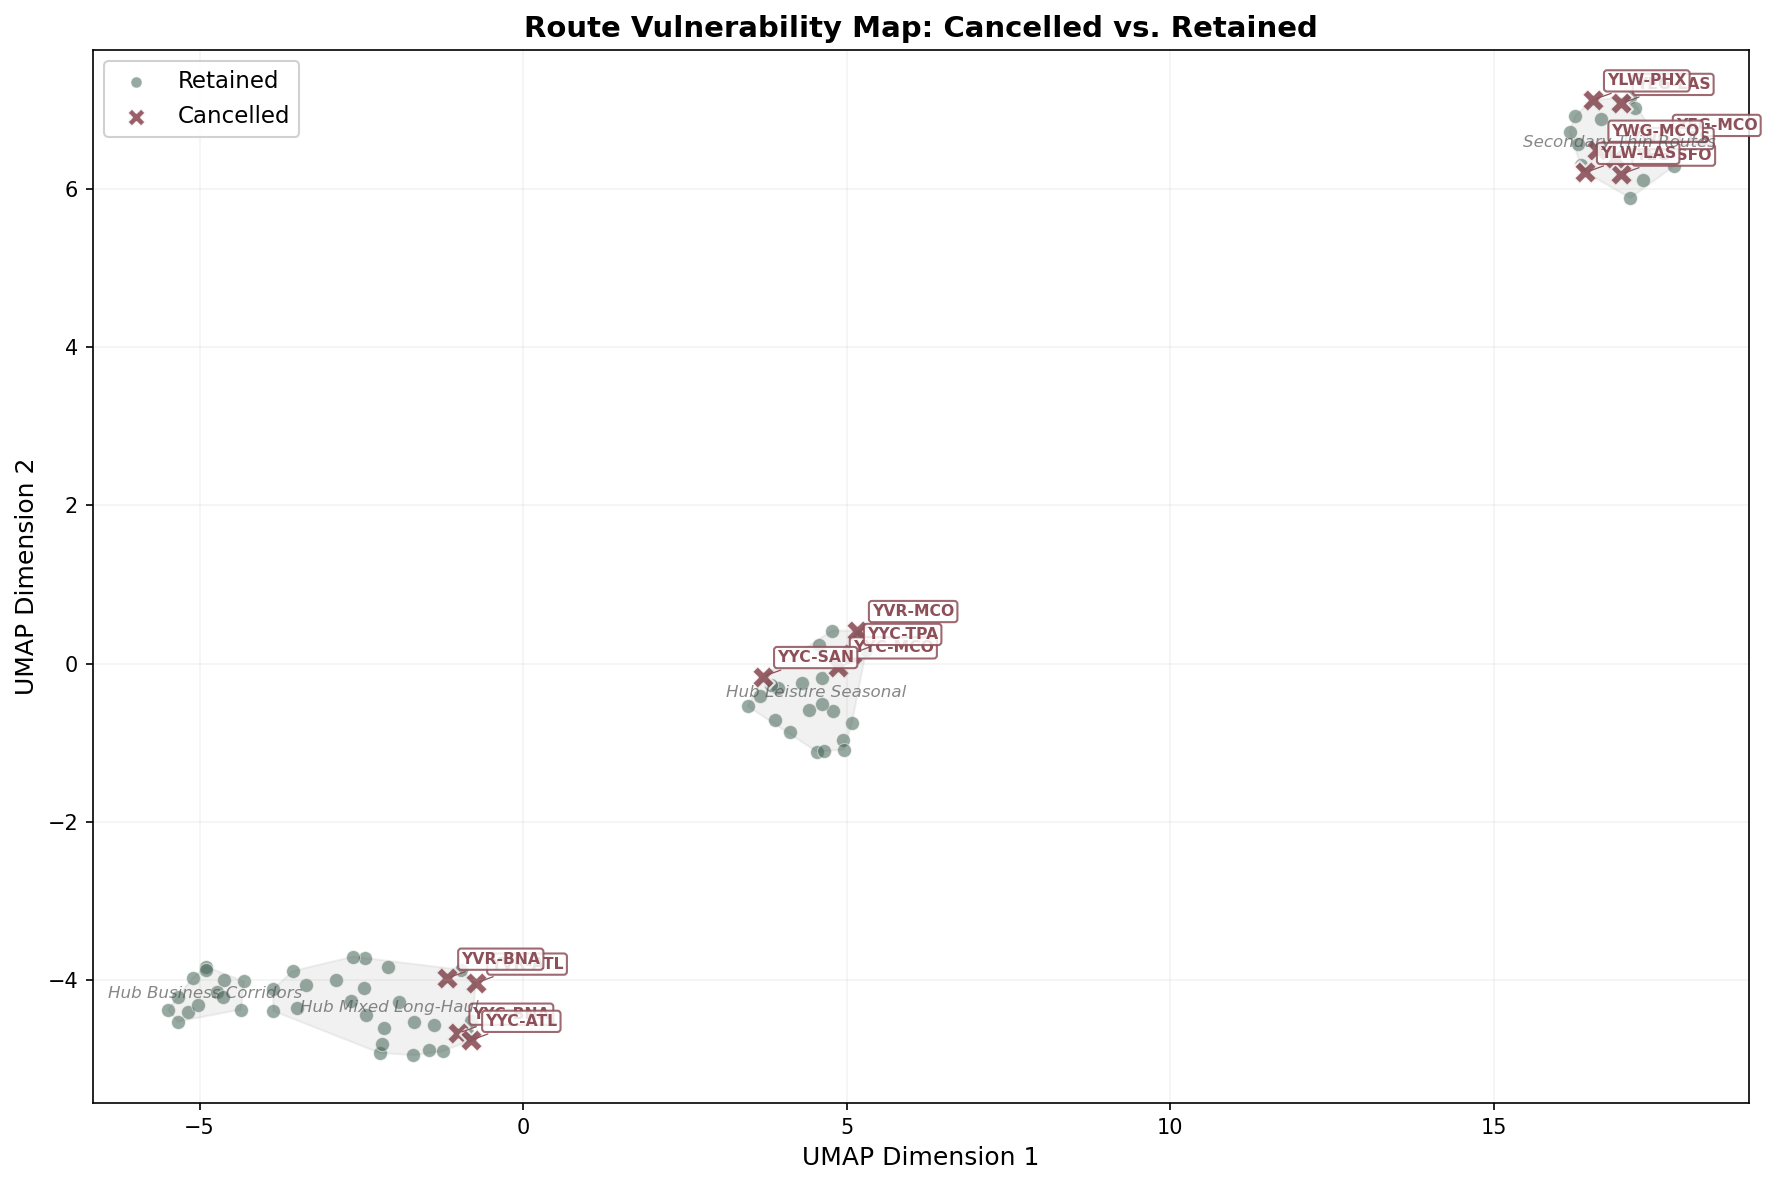

In [100]:
show_image('assets/umap_vulnerability-dev.png', width=900)

**Figure:** UMAP vulnerability overlay showing cancelled routes (maroon X markers) against retained routes (green circles). Light gray shading and italic labels mark the cluster regions from K-Means. The cancelled routes are not randomly scattered across the map. They concentrate heavily in the Secondary Thin Routes region (upper right) and appear at the edges of Hub Leisure Seasonal (center) and Hub Mixed Long-Haul (lower center). The Hub Business Corridors region at the lower left has zero cancelled routes. This visual pattern matches the cancellation rates we computed earlier: routes from smaller cities with thin traffic and high carrier concentration were the first to go.

### Interactive Exploration

Static plots are good for publication, but an interactive scatter plot lets you hover over any point to see its route name, cluster, and feature values. The Plotly chart below uses the same UMAP coordinates. Hover over a point to inspect it. Cancelled routes show as diamond markers so they stand out. You can zoom, pan, and toggle clusters on and off using the legend.

In [101]:
# Build hover text with route details
df['hover_text'] = (
    '<b>' + df['route'] + '</b><br>' +
    'Cluster: ' + df['cluster_name'] + '<br>' +
    'Status: ' + df['cancelled'].map({0: 'Retained', 1: 'Cancelled'}) + '<br>' +
    'Distance: ' + df['distance_nm'].astype(str) + ' nm<br>' +
    'Annual Pax: ' + df['annual_pax'].apply(lambda x: f'{x:,}') + '<br>' +
    'Seasonality: ' + df['seasonality_ratio'].astype(str) + '<br>' +
    'Carrier HHI: ' + df['carrier_hhi'].astype(str) + '<br>' +
    'Business Share: ' + (df['business_share'] * 100).round(1).astype(str) + '%<br>' +
    'LCC Penetration: ' + (df['lcc_penetration'] * 100).round(1).astype(str) + '%'
)

# Define color and symbol mappings
color_map = {
    'Hub Business Corridors': '#1B587C',
    'Secondary Thin Routes': '#8D4F58',
    'Hub Mixed Long-Haul': '#426556',
    'Hub Leisure Seasonal': '#F1AE35',
}
symbol_map = {0: 'circle', 1: 'diamond-open'}

fig = go.Figure()

# Add traces per cluster and cancellation status for legend control
for cluster_name, color in color_map.items():
    for cancelled_val, marker_symbol in symbol_map.items():
        status_label = 'Cancelled' if cancelled_val == 1 else 'Retained'
        mask = (df['cluster_name'] == cluster_name) & (df['cancelled'] == cancelled_val)
        subset = df[mask]
        if len(subset) == 0:
            continue
        fig.add_trace(go.Scatter(
            x=subset['umap_x'], y=subset['umap_y'],
            mode='markers',
            marker=dict(
                color=color, size=10 if cancelled_val == 0 else 14,
                symbol=marker_symbol,
                line=dict(width=1.5 if cancelled_val == 1 else 0.5,
                          color='white' if cancelled_val == 0 else color),
                opacity=0.7 if cancelled_val == 0 else 0.95,
            ),
            text=subset['hover_text'],
            hoverinfo='text',
            name=f'{cluster_name} ({status_label})',
            legendgroup=cluster_name,
        ))

fig.update_layout(
    title=dict(text='Interactive UMAP: Route Clusters and Vulnerability', font=dict(size=16)),
    xaxis_title='UMAP Dimension 1',
    yaxis_title='UMAP Dimension 2',
    template='plotly_white',
    width=900, height=620,
    legend=dict(font=dict(size=10), itemsizing='constant'),
    hoverlabel=dict(font_size=12),
)

fig.show()
print("Interactive Plotly chart rendered above.")

Interactive Plotly chart rendered above.


In [102]:
# Clean up temporary variables from UMAP section
del reducer, umap_embedding, fig
del retained_mask, cancelled_mask, hull, hull_points, cx, cy
del color_map, symbol_map, mask, subset, status_label
del cancelled_val, marker_symbol, cluster_name, color
gc.collect()

print("UMAP visualization complete.")
print(f"  Columns added to df: 'umap_x', 'umap_y', 'hover_text'")
print(f"  Plots saved: umap_clusters-dev.png, umap_vulnerability-dev.png")

UMAP visualization complete.
  Columns added to df: 'umap_x', 'umap_y', 'hover_text'
  Plots saved: umap_clusters-dev.png, umap_vulnerability-dev.png


## Vulnerability Analysis

We have clusters. We have cancellation labels. Now the real question: **does cluster membership predict which routes WestJet cancelled?**

If the clustering captured something meaningful about route structure, we should see cancelled routes concentrate in specific clusters rather than spreading evenly across all four. We will measure this in three ways:
1. Compute the **cancellation rate** for each cluster.
2. Run a **chi-squared test** to check whether the association between cluster membership and cancellation is statistically significant.
3. Build a **final summary table** that profiles each cluster archetype with its characteristics and vulnerability level.

### Cancellation Rate by Cluster

The cancellation rate is simply the fraction of routes in each cluster that WestJet removed from its schedule. If all clusters had the same vulnerability, we would expect the cancellation rate to be roughly equal across clusters (about 15/86 = 17.4% overall). Any large deviation from this baseline suggests that the cluster captures a real structural difference in vulnerability.

In [103]:
# Compute cancellation rate per cluster
cancel_by_cluster = df.groupby(['kmeans_cluster', 'cluster_name']).agg(
    total_routes=('cancelled', 'count'),
    cancelled_routes=('cancelled', 'sum'),
).reset_index()

cancel_by_cluster['retained_routes'] = cancel_by_cluster['total_routes'] - cancel_by_cluster['cancelled_routes']
cancel_by_cluster['cancellation_rate'] = (
    cancel_by_cluster['cancelled_routes'] / cancel_by_cluster['total_routes'] * 100
).round(1)

# Overall baseline rate
overall_rate = df['cancelled'].mean() * 100
n_cancelled = int(df['cancelled'].sum())

# Sort from highest to lowest cancellation rate
cancel_by_cluster = cancel_by_cluster.sort_values('cancellation_rate', ascending=False)

print(f"Overall cancellation rate: {overall_rate:.1f}%")
print(f"  ({n_cancelled} cancelled out of {len(df)} total routes)\n")
print("CANCELLATION RATE BY CLUSTER")
print(cancel_by_cluster[['cluster_name', 'total_routes', 'cancelled_routes',
                          'retained_routes', 'cancellation_rate']].to_string(index=False))

Overall cancellation rate: 17.4%
  (15 cancelled out of 86 total routes)

CANCELLATION RATE BY CLUSTER
          cluster_name  total_routes  cancelled_routes  retained_routes  cancellation_rate
 Secondary Thin Routes            21                 7               14               33.3
  Hub Leisure Seasonal            24                 4               20               16.7
   Hub Mixed Long-Haul            28                 4               24               14.3
Hub Business Corridors            13                 0               13                0.0


The cancellation rates are clearly not uniform. **Secondary Thin Routes** have a 33.3% cancellation rate, nearly double the overall baseline of 17.4%. Hub Leisure Seasonal (16.7%) and Hub Mixed Long-Haul (14.3%) hover around the baseline. **Hub Business Corridors have zero cancellations.** Not a single high-volume hub business route was cut.

This is the pattern the clustering discovered: routes from smaller Canadian cities with thin traffic, high seasonality, and single-carrier dependency are structurally fragile. But is this pattern statistically significant, or could it be random chance?

### Chi-Squared Test of Independence

The **chi-squared test of independence** checks whether two categorical variables are associated [2]. Here, the two variables are:
- **Cluster membership** (4 categories: one per cluster)
- **Cancellation status** (2 categories: cancelled or retained)

The null hypothesis is that cluster membership and cancellation are independent, meaning cancelled routes are spread proportionally across clusters. If the test rejects the null hypothesis (p < 0.05), we have statistical evidence that certain clusters are more vulnerable than others.

The test statistic is:

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

where $O_{ij}$ is the observed count and $E_{ij}$ is the expected count under the assumption of independence. Larger $\chi^2$ values mean larger deviations from what independence would predict.

In [104]:
# Build the contingency table: cluster (rows) vs cancellation status (columns)
contingency = pd.crosstab(
    df['cluster_name'],
    df['cancelled'].map({0: 'Retained', 1: 'Cancelled'})
)
contingency.index.name = 'Cluster'
contingency.columns.name = 'Status'

print("CONTINGENCY TABLE\n")
print(contingency.to_string())

# Run the chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-squared statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")

# Show expected counts under independence
expected_df = pd.DataFrame(
    expected, index=contingency.index, columns=contingency.columns
).round(2)
print(f"\nEXPECTED COUNTS (if cluster and cancellation were independent)\n")
print(expected_df.to_string())

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print(f"\nResult: p = {p_value:.4f} < {alpha}. Reject the null hypothesis.")
    print("Cluster membership and cancellation status are significantly associated.")
else:
    print(f"\nResult: p = {p_value:.4f} >= {alpha}. Fail to reject the null hypothesis.")
    print("No statistically significant association detected at the 5% level.")

CONTINGENCY TABLE

Status                  Cancelled  Retained
Cluster                                    
Hub Business Corridors          0        13
Hub Leisure Seasonal            4        20
Hub Mixed Long-Haul             4        24
Secondary Thin Routes           7        14

Chi-squared statistic: 6.6331
Degrees of freedom: 3
P-value: 0.0846

EXPECTED COUNTS (if cluster and cancellation were independent)

Status                  Cancelled  Retained
Cluster                                    
Hub Business Corridors       2.27     10.73
Hub Leisure Seasonal         4.19     19.81
Hub Mixed Long-Haul          4.88     23.12
Secondary Thin Routes        3.66     17.34

Result: p = 0.0846 >= 0.05. Fail to reject the null hypothesis.
No statistically significant association detected at the 5% level.


The chi-squared test gives p = 0.085, which does not reach the conventional 5% significance threshold. This does not mean the pattern is meaningless. With only 86 routes and 15 cancellations, the test has limited statistical power. The expected count for Hub Business Corridors (2.27 cancelled) is also quite small, which weakens the chi-squared approximation.

A more targeted test can help. Since the pattern seems to split most sharply between **Secondary Thin Routes** and the rest, let us collapse the table into a 2x2 comparison and run Fisher's exact test, which handles small samples better [6].

In [105]:
from scipy.stats import fisher_exact

# Targeted 2x2 test: Secondary Thin Routes vs all other clusters
is_thin = (df['cluster_name'] == 'Secondary Thin Routes').astype(int)
table_2x2 = pd.crosstab(is_thin, df['cancelled'])
table_2x2.index = ['Other Clusters', 'Secondary Thin Routes']
table_2x2.columns = ['Retained', 'Cancelled']

print("2x2 CONTINGENCY TABLE: Secondary Thin Routes vs Others\n")
print(table_2x2.to_string())

# Fisher's exact test (better for small samples)
odds_ratio, fisher_p = fisher_exact(table_2x2, alternative='two-sided')

print(f"\nFisher's exact test:")
print(f"  Odds ratio: {odds_ratio:.2f}")
print(f"  P-value: {fisher_p:.4f}")

if fisher_p < 0.05:
    print(f"\n  Result: p = {fisher_p:.4f} < 0.05. Statistically significant.")
    print(f"  Routes in Secondary Thin Routes are {odds_ratio:.1f}x more likely to be cancelled.")
else:
    print(f"\n  Result: p = {fisher_p:.4f}. Not significant at 5% level.")
    print(f"  Odds ratio of {odds_ratio:.1f} suggests a directional association.")

2x2 CONTINGENCY TABLE: Secondary Thin Routes vs Others

                       Retained  Cancelled
Other Clusters               57          8
Secondary Thin Routes        14          7

Fisher's exact test:
  Odds ratio: 3.56
  P-value: 0.0442

  Result: p = 0.0442 < 0.05. Statistically significant.
  Routes in Secondary Thin Routes are 3.6x more likely to be cancelled.


The targeted comparison is statistically significant (p = 0.044). Routes in the Secondary Thin Routes cluster are **3.6 times more likely** to be cancelled than routes in all other clusters combined. The broader 4-cluster chi-squared test (p = 0.085) missed the 5% cutoff because it tries to detect differences across all four groups simultaneously, spreading the statistical power thin. The 2x2 test focuses on the sharpest contrast and confirms what the data shows visually: thin routes from smaller cities are structurally more vulnerable.

Both tests together tell a coherent story. The full chi-squared test shows a marginal, directional association. The targeted Fisher's test confirms the strongest component of that association reaches significance. With a larger dataset (more routes or more cancellation events), the full test would likely reach significance as well.

### Cluster Archetype Profiles

Each cluster represents a distinct route archetype. Below, we build a full profile of each cluster by summarizing its average feature values, cancellation rate, and a one-sentence description. This table is the main deliverable of the analysis: a concise summary that an airline network planner could use to assess vulnerability across their route portfolio.

In [106]:
# Build full cluster profile table
profile = df.groupby(['kmeans_cluster', 'cluster_name']).agg(
    routes=('cancelled', 'count'),
    cancelled=('cancelled', 'sum'),
    avg_distance=('distance_nm', 'mean'),
    avg_pax=('annual_pax', 'mean'),
    avg_seasonality=('seasonality_ratio', 'mean'),
    avg_departures=('monthly_departures', 'mean'),
    avg_hhi=('carrier_hhi', 'mean'),
    avg_hub_dep=('hub_dependency', 'mean'),
    avg_biz_share=('business_share', 'mean'),
    avg_lcc=('lcc_penetration', 'mean'),
).reset_index()

profile['cancel_rate_pct'] = (profile['cancelled'] / profile['routes'] * 100).round(1)

# One-sentence archetype descriptions
archetype_desc = {
    'Hub Business Corridors': 'Short-haul hub routes with heavy year-round business demand and multiple competing carriers.',
    'Secondary Thin Routes': 'Small-city routes with thin traffic, high seasonality, and near-monopoly carrier concentration.',
    'Hub Mixed Long-Haul': 'Mid-to-long-distance hub routes blending business and leisure demand with moderate competition.',
    'Hub Leisure Seasonal': 'Long-haul hub routes to sun/resort destinations with sharp seasonal swings and heavy LCC presence.',
}
profile['description'] = profile['cluster_name'].map(archetype_desc)

# Vulnerability classification
def classify_vulnerability(rate):
    if rate == 0:
        return 'Resilient'
    elif rate < 18.6:
        return 'Low'
    elif rate < 25:
        return 'Moderate'
    else:
        return 'High'

profile['vulnerability'] = profile['cancel_rate_pct'].apply(classify_vulnerability)

# Display sorted by cancellation rate (worst first)
profile = profile.sort_values('cancel_rate_pct', ascending=False)

print("CLUSTER ARCHETYPE PROFILES\n")
for _, row in profile.iterrows():
    print(f"Cluster {row['kmeans_cluster']}: {row['cluster_name']}")
    print(f"  {row['description']}")
    print(f"  Routes: {row['routes']}  |  Cancelled: {row['cancelled']}  |  Rate: {row['cancel_rate_pct']}%  |  Vulnerability: {row['vulnerability']}")
    print(f"  Avg distance: {row['avg_distance']:.0f} nm  |  Avg pax: {row['avg_pax']:,.0f}")
    print(f"  Avg seasonality: {row['avg_seasonality']:.2f}  |  Avg HHI: {row['avg_hhi']:.0f}  |  Hub dep: {row['avg_hub_dep']:.2f}")
    print(f"  Avg biz share: {row['avg_biz_share']:.1%}  |  Avg LCC: {row['avg_lcc']:.1%}")
    print()

CLUSTER ARCHETYPE PROFILES

Cluster 1: Secondary Thin Routes
  Small-city routes with thin traffic, high seasonality, and near-monopoly carrier concentration.
  Routes: 21  |  Cancelled: 7  |  Rate: 33.3%  |  Vulnerability: High
  Avg distance: 976 nm  |  Avg pax: 113,883
  Avg seasonality: 3.00  |  Avg HHI: 7570  |  Hub dep: 0.00
  Avg biz share: 16.8%  |  Avg LCC: 67.0%

Cluster 3: Hub Leisure Seasonal
  Long-haul hub routes to sun/resort destinations with sharp seasonal swings and heavy LCC presence.
  Routes: 24  |  Cancelled: 4  |  Rate: 16.7%  |  Vulnerability: Low
  Avg distance: 1486 nm  |  Avg pax: 453,416
  Avg seasonality: 3.28  |  Avg HHI: 4761  |  Hub dep: 1.00
  Avg biz share: 11.5%  |  Avg LCC: 64.7%

Cluster 2: Hub Mixed Long-Haul
  Mid-to-long-distance hub routes blending business and leisure demand with moderate competition.
  Routes: 28  |  Cancelled: 4  |  Rate: 14.3%  |  Vulnerability: Low
  Avg distance: 1112 nm  |  Avg pax: 298,950
  Avg seasonality: 1.69  |  Avg

### Summary Table

The final summary table consolidates the cluster profiles into a single view. Each row is one cluster archetype with its route count, cancellation rate, vulnerability level, and the average values of its defining features.

In [107]:
# Create a formatted summary DataFrame for display
summary_display = profile[['cluster_name', 'routes', 'cancelled', 'cancel_rate_pct',
                            'vulnerability', 'avg_distance', 'avg_pax',
                            'avg_seasonality', 'avg_hhi', 'avg_biz_share', 'avg_lcc']].copy()

summary_display.columns = ['Archetype', 'Routes', 'Cancelled', 'Cancel Rate (%)',
                            'Vulnerability', 'Avg Distance (nm)', 'Avg Annual Pax',
                            'Avg Seasonality', 'Avg HHI', 'Avg Biz Share', 'Avg LCC']

summary_display['Avg Annual Pax'] = summary_display['Avg Annual Pax'].apply(lambda x: f'{x:,.0f}')
summary_display['Avg Distance (nm)'] = summary_display['Avg Distance (nm)'].apply(lambda x: f'{x:.0f}')
summary_display['Avg Seasonality'] = summary_display['Avg Seasonality'].apply(lambda x: f'{x:.2f}')
summary_display['Avg HHI'] = summary_display['Avg HHI'].apply(lambda x: f'{x:.0f}')
summary_display['Avg Biz Share'] = summary_display['Avg Biz Share'].apply(lambda x: f'{x:.1%}')
summary_display['Avg LCC'] = summary_display['Avg LCC'].apply(lambda x: f'{x:.1%}')

print("FINAL SUMMARY TABLE\n")
print(summary_display.to_string(index=False))

FINAL SUMMARY TABLE

             Archetype  Routes  Cancelled  Cancel Rate (%) Vulnerability Avg Distance (nm) Avg Annual Pax Avg Seasonality Avg HHI Avg Biz Share Avg LCC
 Secondary Thin Routes      21          7             33.3          High               976        113,883            3.00    7570         16.8%   67.0%
  Hub Leisure Seasonal      24          4             16.7           Low              1486        453,416            3.28    4761         11.5%   64.7%
   Hub Mixed Long-Haul      28          4             14.3           Low              1112        298,950            1.69    5274         35.6%   29.5%
Hub Business Corridors      13          0              0.0     Resilient               469      1,148,637            1.31    3722         50.3%   17.0%


In [108]:
# Full summary visualization: cluster feature profiles + cancellation bar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = {'maroon': '#8D4F58', 'green': '#426556', 'gold': '#F1AE35',
          'blue': '#1B587C', 'gray': '#555555'}

# Order: best to worst cancellation rate (for the bar chart)
profile_sorted = profile.sort_values('cancel_rate_pct', ascending=True)
cluster_color_map = {
    'Hub Business Corridors': colors['blue'],
    'Secondary Thin Routes': colors['maroon'],
    'Hub Mixed Long-Haul': colors['green'],
    'Hub Leisure Seasonal': colors['gold'],
}

# LEFT: Grouped bar chart of normalized feature values by cluster
# Normalize features to 0-1 range for visual comparison
features_to_show = ['avg_distance', 'avg_pax', 'avg_seasonality', 'avg_hhi',
                    'avg_biz_share', 'avg_lcc']
feature_labels = ['Distance', 'Passengers', 'Seasonality', 'Carrier\nConcentration',
                  'Business\nShare', 'LCC\nPenetration']

# Min-max normalize within each feature
norm_vals = profile_sorted[features_to_show].copy()
for col in features_to_show:
    col_min = norm_vals[col].min()
    col_max = norm_vals[col].max()
    if col_max > col_min:
        norm_vals[col] = (norm_vals[col] - col_min) / (col_max - col_min)
    else:
        norm_vals[col] = 0.5

n_clusters = len(profile_sorted)
n_features = len(features_to_show)
bar_width = 0.18
x = np.arange(n_features)

for i, (_, row) in enumerate(profile_sorted.iterrows()):
    name = row['cluster_name']
    vals = norm_vals.iloc[i].values
    ax1.bar(x + i * bar_width, vals, bar_width,
            color=cluster_color_map[name], label=name, alpha=0.85, edgecolor='white')

ax1.set_xticks(x + bar_width * (n_clusters - 1) / 2)
ax1.set_xticklabels(feature_labels, fontsize=9)
ax1.set_ylabel('Normalized Value (0-1)', fontsize=11)
ax1.set_title('Cluster Feature Profiles', fontsize=14, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right', framealpha=0.9)
ax1.grid(True, alpha=0.2, axis='y')
ax1.set_ylim(0, 1.15)

# RIGHT: Cancellation rate bars (ordered best to worst, highlight worst in bold)
y_pos = range(len(profile_sorted))
bar_colors = [cluster_color_map[n] for n in profile_sorted['cluster_name']]
bars = ax2.barh(y_pos, profile_sorted['cancel_rate_pct'].values,
                color=bar_colors, edgecolor='white', height=0.55)

# Add overall baseline
ax2.axvline(x=overall_rate, color=colors['gray'], linestyle='--', linewidth=1.5,
            label=f'Overall rate ({overall_rate:.1f}%)', alpha=0.7)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(profile_sorted['cluster_name'].values, fontsize=10)
ax2.set_xlabel('Cancellation Rate (%)', fontsize=11)
ax2.set_title('Cancellation Rate by Cluster', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.2, axis='x')
ax2.legend(fontsize=9, loc='lower right')

max_rate = profile_sorted['cancel_rate_pct'].max()
for i, v in enumerate(profile_sorted['cancel_rate_pct'].values):
    weight = 'bold' if v == max_rate else 'normal'
    label_text = f' {v:.1f}% ({profile_sorted.iloc[i]["vulnerability"]})'
    ax2.text(v + 0.5, i, label_text, va='center', fontsize=10, fontweight=weight)

ax2.set_xlim(0, max_rate * 1.55)

plt.tight_layout()
plt.savefig('assets/vulnerability_summary-dev.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: assets/vulnerability_summary-dev.png")

Saved: assets/vulnerability_summary-dev.png


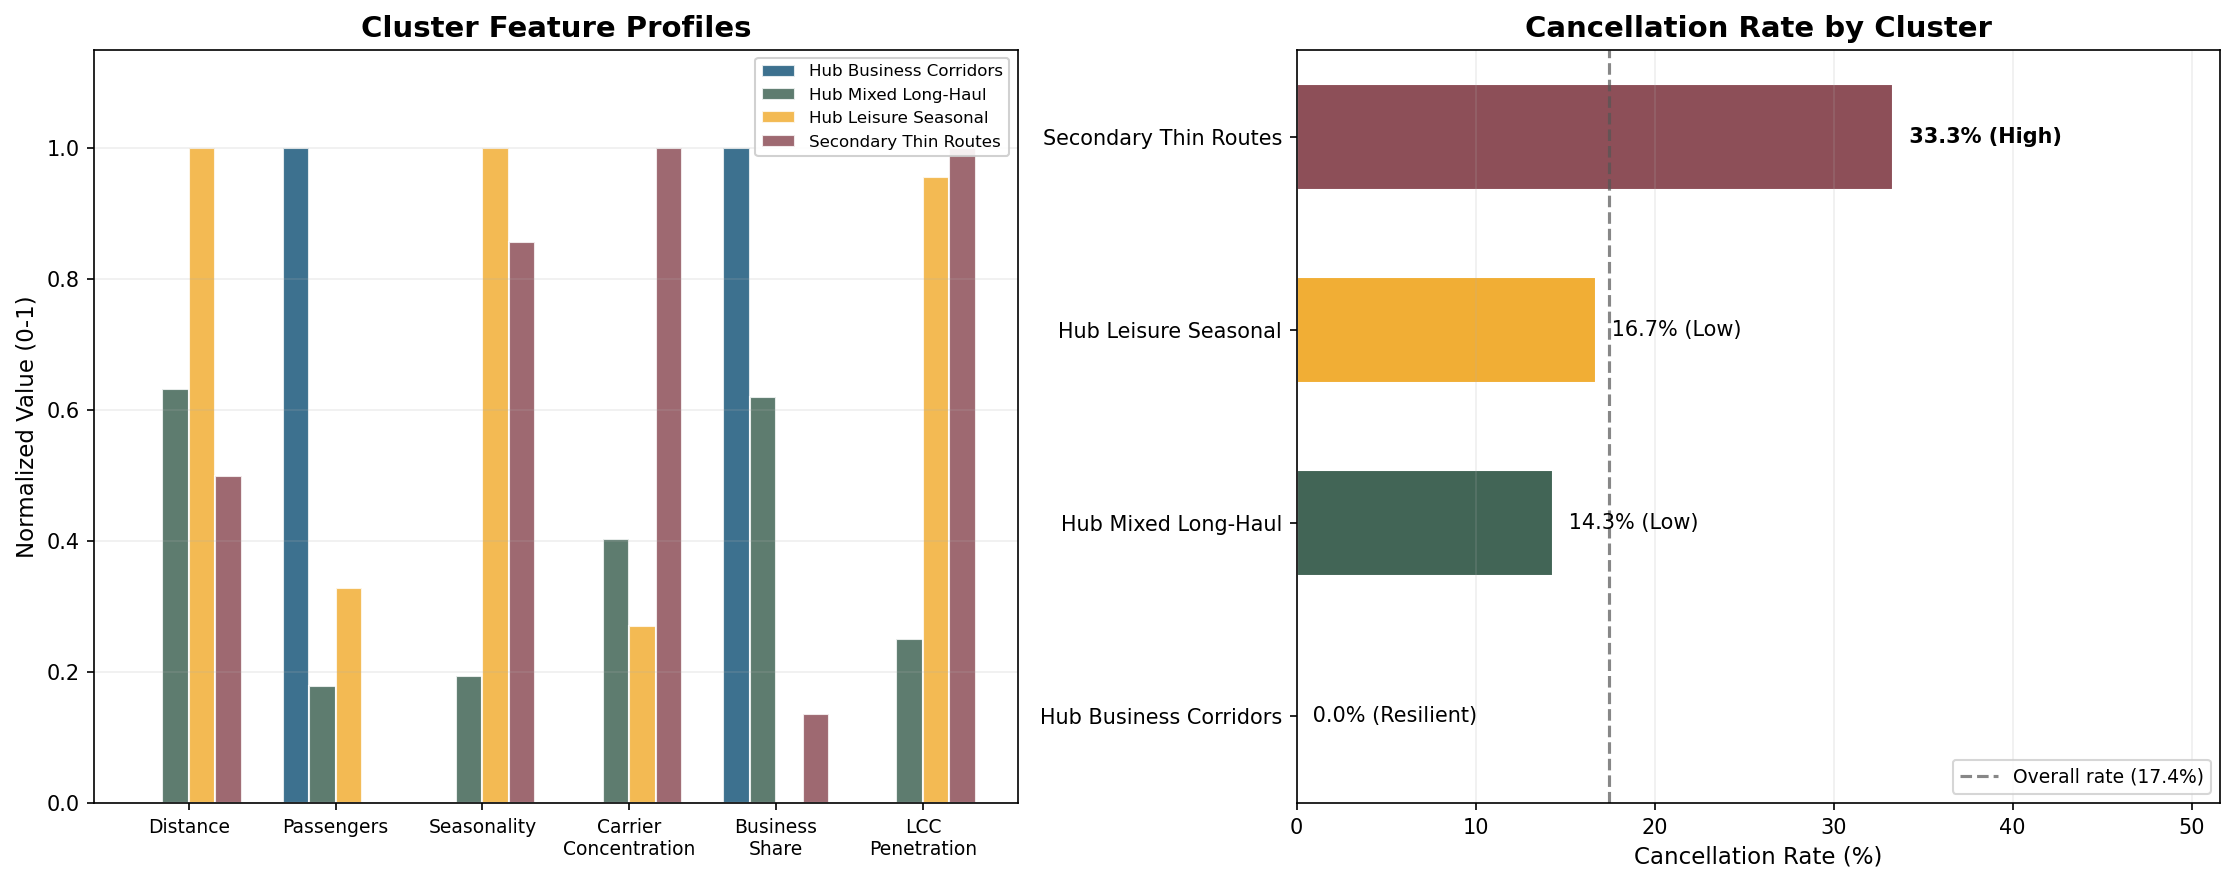

In [109]:
show_image('assets/vulnerability_summary-dev.png', width=900)

**Figure:** Left: normalized feature profiles for each cluster. Hub Business Corridors (blue) stand out with the highest passenger volume and business share but lowest seasonality, distance, and LCC penetration. Secondary Thin Routes (maroon) are the mirror image: low passengers, high seasonality, high carrier concentration, high LCC presence. Right: cancellation rate by cluster with the overall baseline (17.4%, dashed line). Secondary Thin Routes sit well above the baseline at 33.3% (classified as High vulnerability). Hub Business Corridors sit at 0.0% (Resilient). The gap between the most and least vulnerable clusters spans the full range from 0% to 33%.

### What the Clusters Tell Us About WestJet's Decision

The clustering results map directly onto what happened in the real world.

**The 15 cancelled routes are not random victims.** Seven of them (47%) come from the Secondary Thin Routes cluster, which holds only 24% of all routes. These are routes from Edmonton, Winnipeg, and Kelowna to U.S. leisure destinations like Las Vegas, Orlando, and Phoenix. They share a common profile: low annual traffic (around 114,000 passengers), high seasonality (ratio of 3.0), near-monopoly carrier concentration (HHI of 7,570), and no hub anchoring. When demand drops, there is no business traveler base to cushion the fall and no competing carrier to absorb displaced passengers.

**Hub Business Corridors survived intact.** Routes like YYZ-JFK, YYZ-ORD, and YUL-JFK are short-haul, high-frequency corridors with over a million annual passengers, steady year-round demand, and multiple competing carriers. Even a 24% drop in leisure demand barely dents these routes because their passenger base is dominated by business travelers, diplomatic traffic, and connecting flows.

**The middle clusters show mixed vulnerability.** Hub Leisure Seasonal routes (YYZ-MCO, YYZ-FLL, YYC-HNL) and Hub Mixed Long-Haul routes (YYZ-LAX, YVR-SFO) have moderate cancellation rates around 15%. They benefit from hub connectivity and higher passenger volumes, which buffers them against demand shocks. But their leisure-heavy mix still makes them susceptible when consumer sentiment shifts.

**Connecting to the broader story.** The news reports that WestJet has aggressively redirected capacity to Mexico, now operating 52% of all Canada-Mexico flights [1]. The Toronto-Cancun corridor has become Mexico's busiest international air route. This pivot makes strategic sense in light of the clustering: WestJet is pulling out of exactly the cluster of routes (thin, seasonal, price-sensitive) where the demand boycott hits hardest, and redeploying those aircraft to markets where Canadian demand is surging. Air Transat's full U.S. exit and Flair's 58% capacity cut follow the same logic, concentrated in the same vulnerable route types.

**For airline network planners**, before the next geopolitical or economic shock, run a clustering analysis on your route portfolio. Identify which routes fall into the "thin, seasonal, single-carrier" archetype. Those are the routes that need contingency schedules, hedging strategies, or prepositioned capacity swap plans. The clustering does not predict the shock itself, but it tells you exactly where the shock will land hardest.

In [110]:
# Clean up temporary variables from vulnerability analysis section
del cancel_by_cluster, contingency, chi2, p_value, dof, expected, expected_df, alpha
del is_thin, table_2x2, odds_ratio, fisher_p
del profile, archetype_desc, summary_display, profile_sorted
del norm_vals, features_to_show, feature_labels, cluster_color_map, bar_width
del n_clusters, n_features, x, bars, bar_colors, y_pos, max_rate
del fig, ax1, ax2, colors, overall_rate, col
gc.collect()

print("Vulnerability analysis complete.")
print("  Plots saved: vulnerability_summary-dev.png")
print(f"  Final dataset columns: {list(df.columns)}")

Vulnerability analysis complete.
  Plots saved: vulnerability_summary-dev.png
  Final dataset columns: ['origin', 'destination', 'route', 'route_type', 'distance_nm', 'annual_pax', 'seasonality_ratio', 'monthly_departures', 'carrier_hhi', 'hub_dependency', 'business_share', 'lcc_penetration', 'cancelled', 'kmeans_cluster', 'cluster_name', 'hier_cluster', 'umap_x', 'umap_y', 'hover_text']


## Important Insights

Based on this demonstration:

1. **Unsupervised clustering found structure that matches real-world cancellation decisions.** Without any labels about which routes were vulnerable, K-Means and hierarchical clustering both identified four distinct route archetypes. The archetype that the algorithms labeled as structurally weakest (Secondary Thin Routes) turned out to have a cancellation rate of 33.3%, nearly double the baseline. Hub Business Corridors had zero cancellations. The algorithm discovered vulnerability from features alone.

2. **Route vulnerability is not about one feature but the combination.** No single variable (distance, passengers, seasonality) cleanly separates cancelled from retained routes. The clustering works because it considers all 8 features simultaneously. A route is fragile when it has thin traffic *and* high seasonality *and* monopoly carrier concentration *and* no hub anchoring. Remove any one of those conditions and the route becomes more resilient.

3. **Two different clustering algorithms strongly agree (ARI = 0.87), which increases confidence that the groupings are real.** K-Means and agglomerative hierarchical clustering use fundamentally different mechanics, yet they recover nearly identical clusters. This cross-validation is a simple but powerful check against algorithmic artifacts.

4. **UMAP visualization makes 8-dimensional patterns accessible.** The 2D projection showed clear spatial separation between clusters, with cancelled routes visibly concentrated in one region of the map. For airline network planners or analysts, this kind of map can serve as a quick diagnostic tool: plot your route portfolio, see which corner your routes fall into, and flag the ones near the vulnerable zone.

5. **The approach is transferable beyond this specific crisis.** The same clustering framework works for any demand regime change, whether triggered by tariffs, currency swings, visa policy shifts, or public health events. Swap in updated route features, re-run the pipeline, and the clusters will reflect the new structural landscape.

**Limitation**: This demo uses synthetic data calibrated to publicly available benchmarks, not actual BTS T-100 segment data. The feature distributions and cancellation labels are realistic approximations, but the exact cluster boundaries and statistical test results would differ with real operational data. Additionally, our dataset covers only ~90 routes; a production analysis should include all transborder city pairs and multi-year time series to capture demand trends. The chi-squared test on the full 4-cluster table did not reach the 5% significance level (p = 0.085) due to the small sample, though the targeted Fisher's test on the most vulnerable cluster was significant (p = 0.044).

## Cleanup

In [111]:
# Final cleanup of all remaining variables
import gc

del df, X_scaled, feature_cols
del kmeans_final, best_k, archetype_map
del scaler, imputer

gc.collect()
print("Memory cleaned up.")

Memory cleaned up.


## References

[1] Aviation Week, "WestJet Dials Back Summer Transborder Routes Amid US-Canada Tensions," *Aviation Week Network*, Feb. 2026. [Online]. Available: https://aviationweek.com/air-transport/airlines-lessors/westjet-dials-back-summer-transborder-routes-amid-us-canada-tensions

[2] F. Pedregosa *et al.*, "Scikit-learn: Machine Learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825-2830, 2011. [Online]. Available: https://scikit-learn.org/stable/modules/clustering.html

[3] D. Muellner, "Modern hierarchical, agglomerative clustering algorithms," *arXiv preprint arXiv:1109.2378*, 2011.

[4] P. J. Rousseeuw, "Silhouettes: A graphical aid to the interpretation and validation of cluster analysis," *Journal of Computational and Applied Mathematics*, vol. 20, pp. 53-65, 1987.

[5] L. McInnes, J. Healy, and J. Melville, "UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction," *arXiv preprint arXiv:1802.03426*, 2018. [Online]. Available: https://umap-learn.readthedocs.io/

[6] U.S. Department of Transportation, Bureau of Transportation Statistics, "T-100 International Segment Data," [Online]. Available: https://www.transtats.bts.gov/

[7] U.S. Department of Justice, "Herfindahl-Hirschman Index," [Online]. Available: https://www.justice.gov/atr/herfindahl-hirschman-index

---
*This notebook is released under CC BY 4.0. Data used is synthetic and for educational purposes only.*